input_file = 'D:/Research/microfluid_pgl_meg/mf_.5fl_5pgl_1/asymetric_distribution/series_stat/angle_data.xlsx' 绘制不对称性向量与运动方向夹角的角度直方图

Analysis complete. R-value: 0.3013, p-value: 5.3375e-04


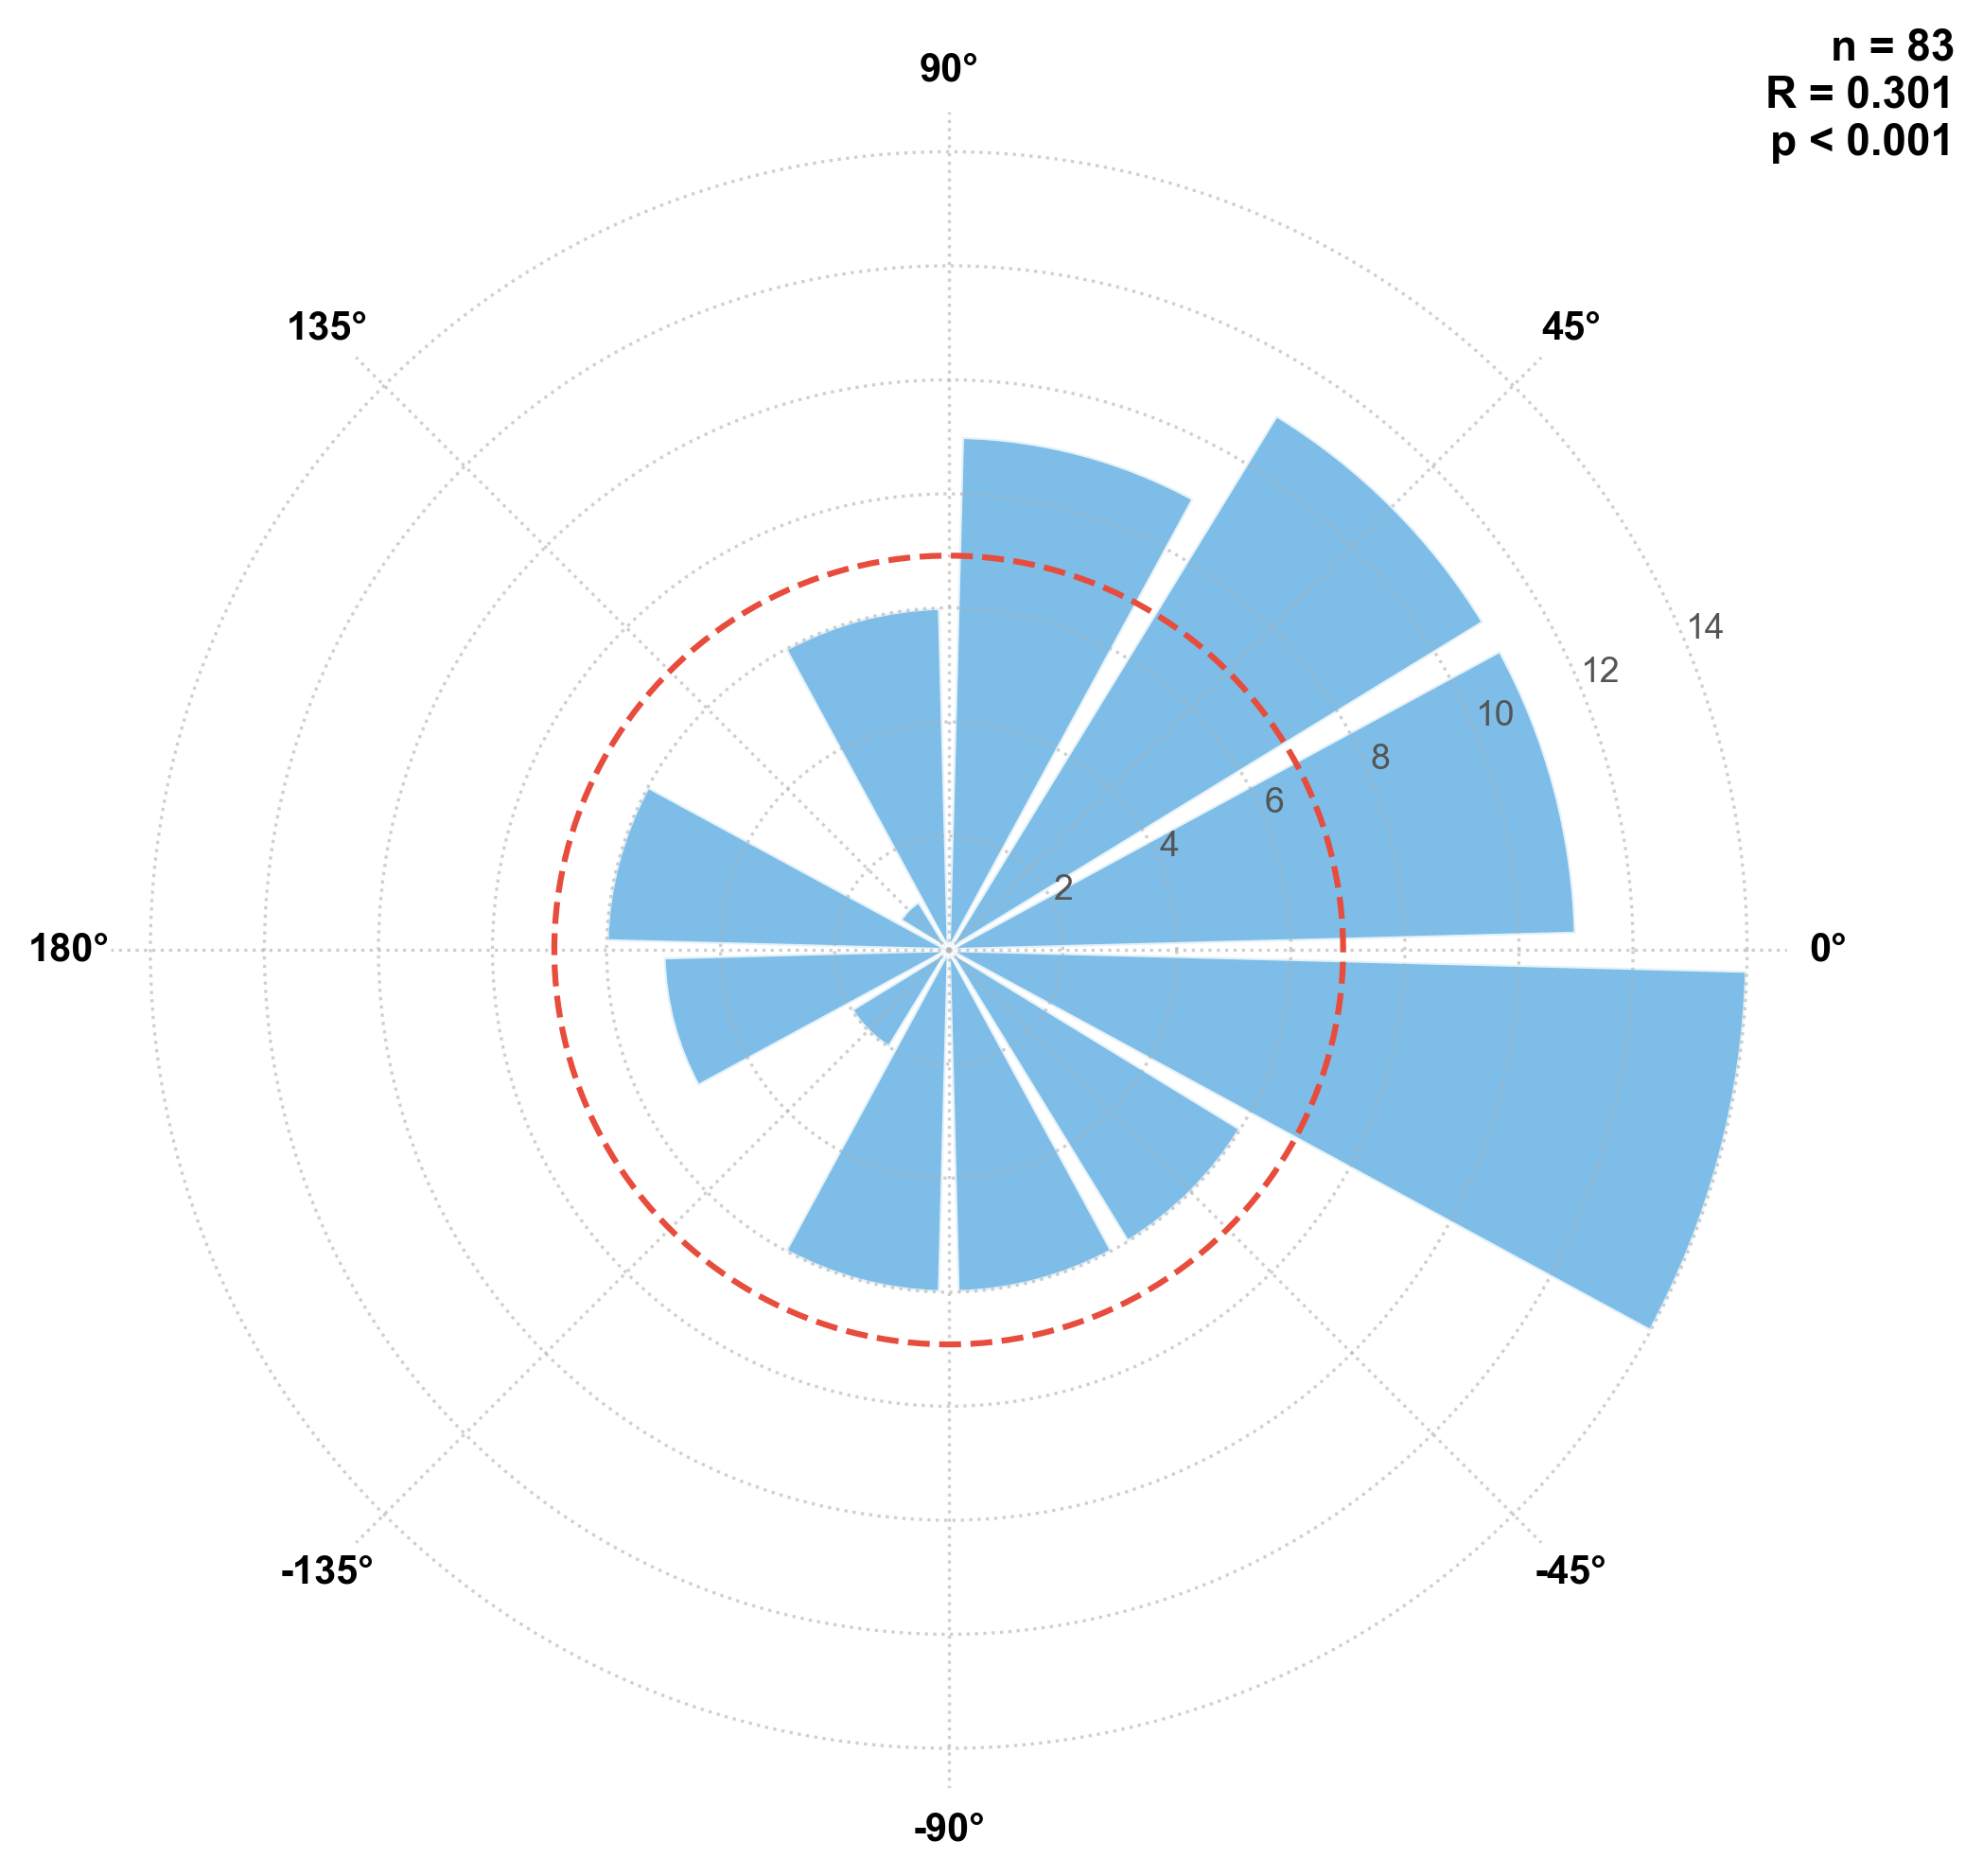

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================= CONFIGURATION AREA ================= #
input_file = 'D:/Research/microfluid_pgl_meg/mf_.5fl_5pgl_1/asymetric_distribution/series_stat/angle_data.xlsx'
column_name = 'angle' 
output_file = 'directional_analysis_polar.svg'

use_dummy_data = True  # Set to False for real data
num_bins = 12 

# Visual Constants
BAR_COLOR = '#5DADE2'
UNIFORM_COLOR = '#E74C3C' # Red for the reference circle
FONT_NAME = 'Arial'
# ====================================================== #

# 1. Data Processing
df = pd.read_excel(input_file)

angles = df[column_name].values
radians = np.deg2rad(angles)
n_samples = len(angles)

# 2. Directional Statistics (Rayleigh Test)
# Calculate components of the resultant vector
sum_cos = np.sum(np.cos(radians))
sum_sin = np.sum(np.sin(radians))

# Resultant vector length (R) - indicates degree of directionality
R_length = np.sqrt(sum_cos**2 + sum_sin**2) / n_samples
# Rayleigh's Z statistic and p-value approximation
z_stat = n_samples * (R_length**2)
p_value = np.exp(-z_stat) 

# 3. Histogram Calculation
bin_counts, bin_edges = np.histogram(radians, bins=num_bins, range=(-np.pi, np.pi))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
uniform_level = n_samples / num_bins # Theoretical frequency if distribution was random

# 4. Plotting
plt.rcParams['font.family'] = FONT_NAME
fig = plt.figure(figsize=(7, 7), dpi=300)
ax = fig.add_subplot(111, projection='polar')

# Setup orientation
ax.set_theta_zero_location('E')
ax.set_theta_direction(1)

# Plot bars (zorder 2)
ax.bar(bin_centers, bin_counts, width=bin_width*0.9, color=BAR_COLOR, 
       edgecolor='white', linewidth=1, alpha=0.8, zorder=2)

# Plot Uniform Distribution Circle (zorder 3)
theta_full = np.linspace(0, 2*np.pi, 200)
ax.plot(theta_full, [uniform_level]*200, color=UNIFORM_COLOR, 
        linestyle='--', linewidth=1.5, label='Uniform Expected', zorder=3)

# 5. Styling and Labels
# Set ticks to -180 to 180
degree_ticks = np.arange(0, 360, 45)
ax.set_xticks(np.deg2rad(degree_ticks))
ax.set_xticklabels([f"{d}°" if d <= 180 else f"{d-360}°" for d in degree_ticks], 
                   fontweight='bold', fontsize=10)

# Ensure radial labels are on top (zorder 10)
ax.set_axisbelow(False)
plt.yticks(fontsize=9, color='#555555', zorder=10)
ax.set_rlabel_position(22.5)
ax.grid(True, linestyle=':', alpha=0.6, zorder=1)
ax.spines['polar'].set_visible(False)

# 6. Statistical Annotation
stats_text = (f"n = {n_samples}\n"
              f"R = {R_length:.3f}\n"
              f"p < {0.001 if p_value < 0.001 else round(p_value, 3)}")

# Place text box in the upper right corner of the figure
ax.text(1.1, 1.05, stats_text, transform=ax.transAxes, 
        fontsize=11, fontweight='bold', va='top', ha='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# 7. Final Output
plt.tight_layout()
plt.savefig(output_file, format='svg', transparent=True)
print(f"Analysis complete. R-value: {R_length:.4f}, p-value: {p_value:.4e}")
plt.show()

归一化原点发散图 (Origin-Normalized Trajectories)

形式：将所有凝聚体的起始坐标 $(x_0, y_0)$ 强制归零到 $(0,0)$。

内容：绘制所有 $t$ 时刻的 $(x_t - x_0, y_t - y_0)$。

顶级期刊细节：由于数据量大，不要画实线。使用半透明的散点（Alpha=0.1）或者核密度估计图 (Kernel Density Estimation, KDE) 轮廓线。

结果：如果存在Marangoni效应，图像应呈现为一个偏向梯度方向的“彗星”或“扇形”，而不是各向同性的圆形。

根据凝聚体的尺寸（荧光强度）对轨迹进行颜色编码。



Processing HMGL-_Control_Gradient...
Figure saved to: D:/Research/microfluid_pgl_meg/trackmate_series/HMGL-_Control_Gradient_Directionality_Analysis.svg


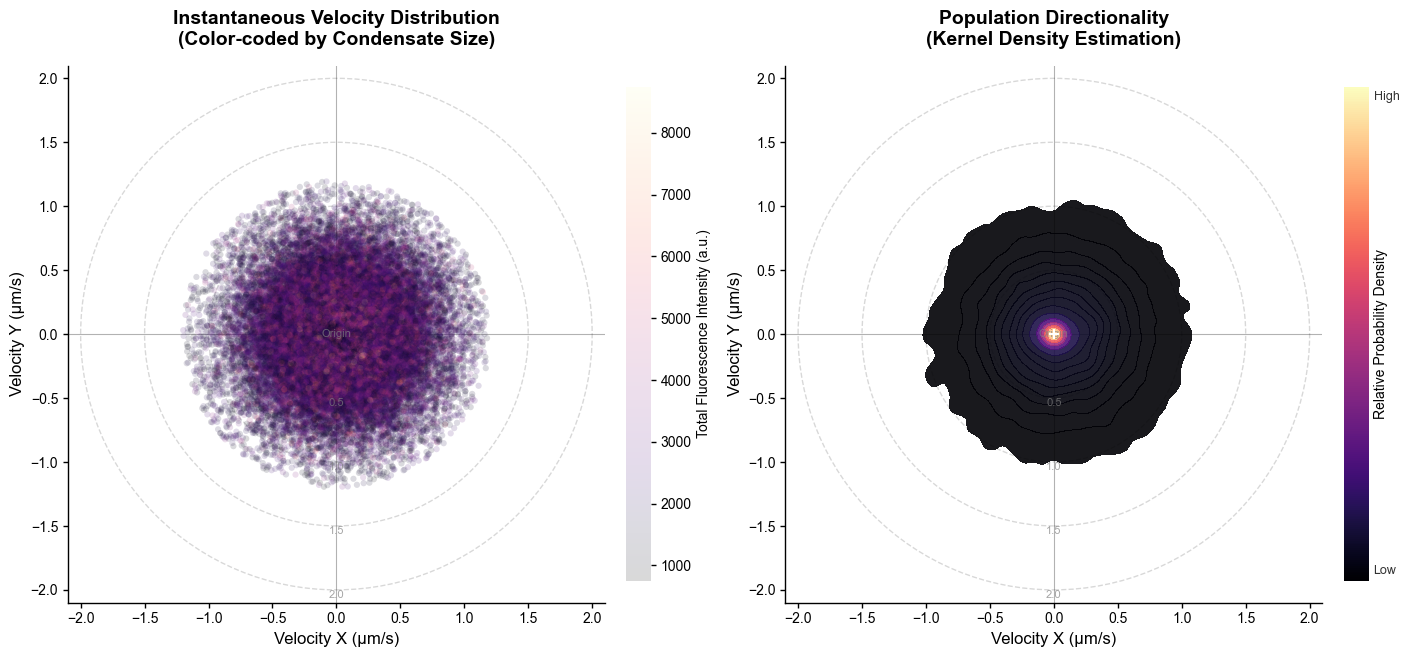

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
import matplotlib.patches as patches
import matplotlib.cm as cm
import os

# ==========================================
# 1. 配置参数 (Configuration)
# ==========================================
CONFIG = {
    'time_interval': 5.0,        # 每一帧的时间间隔 (秒)
    'pixel_size': 1.0,           # 如果坐标已经是微米则设为1.0，如果是像素需在此转换
    'velocity_min': 0.01,        # 最小速度阈值 (um/s) - 过滤静止/抖动噪声
    'velocity_max': 2,        # 最大速度阈值 (um/s) - 过滤跟踪错误的飞点
    'font_family': 'Arial',      # 顶级期刊常用字体
    'save_format': 'svg',        # 矢量格式
    'colormap': 'magma',         # 推荐色图 (黑-紫-红-黄，视觉感强且对色盲友好)
    'alpha': 0.15,               # 散点透明度
    'dpi': 300
}

# 设置全局绘图风格
plt.rcParams['font.family'] = CONFIG['font_family']
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0

# ==========================================
# 2. 数据处理核心模块 (Data Processing)
# ==========================================

def load_trackmate_csv(filepath):
    """
    读取Trackmate CSV，自动跳过前4行单位说明，从第5行开始读取数据
    """
    try:
        # header=3 表示第4行是列名 (0-based index)，数据从第5行开始
        df = pd.read_csv(filepath)
        # 将Na
        df = df.dropna(how='all')
        return df
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def process_experiment_data(files_dict):
    """
    处理单组实验数据：连接 Edges 和 Spots 信息
    """
    print(f"Processing {files_dict['name']}...")
    
    # 1. 加载数据
    spots_df = load_trackmate_csv(files_dict['spots'])
    edges_df = load_trackmate_csv(files_dict['edges'])
    
    if spots_df is None or edges_df is None:
        return None

    # 2. 建立 Spot 索引字典 (Label -> {X, Y, Intensity})
    # 注意：CSV中Label列通常是 "ID12345"，我们需要建立快速查找
    # 假设 'LABEL' 是唯一标识符
    spot_map = spots_df.set_index('LABEL')[
        ['POSITION_X', 'POSITION_Y', 'TOTAL_INTENSITY_CH1']
    ].to_dict('index')

    vectors = []

    # 3. 遍历 Edges 计算向量
    for _, row in edges_df.iterrows():
        edge_label = str(row['LABEL'])
        
        # 解析 "IDxxxxx -> IDyyyyy"
        if '→' in edge_label:
            separator = '→'
        elif '_' in edge_label:
            separator = '_'
        else:
            continue
            
        try:
            source_id, target_id = edge_label.split(separator)
            source_id = source_id.strip()
            target_id = target_id.strip()
            
            # 获取源点和目标点信息
            if source_id in spot_map and target_id in spot_map:
                s_data = spot_map[source_id]
                t_data = spot_map[target_id]
                
                # 坐标 (微米)
                x1, y1 = s_data['POSITION_X'], s_data['POSITION_Y']
                x2, y2 = t_data['POSITION_X'], t_data['POSITION_Y']
                
                # 荧光强度 (取平均)
                intensity = (s_data['TOTAL_INTENSITY_CH1'] + t_data['TOTAL_INTENSITY_CH1']) / 2
                
                # 计算位移向量 (原点归一化)
                dx = (x2 - x1) * CONFIG['pixel_size']
                dy = (y2 - y1) * CONFIG['pixel_size']
                
                # 计算距离和速度
                distance = np.sqrt(dx**2 + dy**2)
                velocity = distance / CONFIG['time_interval']
                
                # 4. 阈值过滤 (Quality Control)
                if CONFIG['velocity_min'] <= velocity <= CONFIG['velocity_max']:
                    vectors.append({
                        'dx': dx,
                        'dy': dy,
                        'velocity': velocity, # 这里的dx, dy除以时间即为速度分量，画图时我们画位移向量，但物理意义对应速度
                        'intensity': intensity,
                        'v_x': dx / CONFIG['time_interval'], # X轴速度 um/s
                        'v_y': dy / CONFIG['time_interval']  # Y轴速度 um/s
                    })
                    
        except Exception as e:
            continue

    return pd.DataFrame(vectors)

# ==========================================
# 3. 可视化绘图模块 (Visualization)
# ==========================================

# ==========================================
# 3. 可视化绘图模块 (Visualization)
# ==========================================

def plot_origin_normalized_vectors(data_df, output_name, save_dir):
    """
    绘制两张图：
    1. 散点图 (Scatter): 颜色代表荧光强度 (尺寸 proxy)
    2. 密度图 (KDE): 展示群体的主流向，带Colorbar
    """
    if data_df.empty:
        print("No data passing filters.")
        return

    # 创建画布：1行2列
    fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
    
    # 提取数据
    vx = data_df['v_x']
    vy = data_df['v_y']
    intensities = data_df['intensity']
    
    # 自动计算坐标轴范围，但确保至少覆盖 CONFIG['velocity_max']
    data_max = max(np.max(np.abs(vx)), np.max(np.abs(vy)))
    max_limit = max(data_max, CONFIG['velocity_max']) * 1.05
    limit = [-max_limit, max_limit]

    # --- 辅助函数：绘制同心圆网格 ---
    def draw_grid_circles(ax, max_val):
        # 根据速度范围 0.01 - 2.0，生成更密集的圆环：0.5, 1.0, 1.5, 2.0
        circles = [0.5, 1.0, 1.5, 2.0]
        # 如果数据范围比2大很多，适当增加
        if max_val > 2.2:
            circles.extend([2.5, 3.0, 4.0, 5.0])
            
        for r in circles:
            if r <= max_val * 1.1: # 只画在视野内的
                circle = patches.Circle((0, 0), r, fill=False, edgecolor='gray', linestyle='--', alpha=0.3, zorder=0)
                ax.add_patch(circle)
                # 标注速度值
                ax.text(0, -r, f'{r}', ha='center', va='top', fontsize=8, color='gray', alpha=0.7)
        
        # 标注单位
        ax.text(0, 0, 'Origin', ha='center', va='center', fontsize=8, color='gray', alpha=0.7)
        # 十字准线
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.3, zorder=0)
        ax.axvline(0, color='black', linewidth=0.8, alpha=0.3, zorder=0)

    # --- Plot A: Scatter (Intensity Coded) ---
    ax_sc = axes[0]
    draw_grid_circles(ax_sc, max_limit)

    # 散点绘制
    sc = ax_sc.scatter(vx, vy, c=intensities, cmap=CONFIG['colormap'], 
                       s=20, alpha=CONFIG['alpha'], edgecolors='none', zorder=2)
    
    # 装饰 Plot A
    ax_sc.set_title('Instantaneous Velocity Distribution\n(Color-coded by Condensate Size)', fontsize=14, fontweight='bold', pad=15)
    ax_sc.set_xlabel('Velocity X (µm/s)', fontsize=12)
    ax_sc.set_ylabel('Velocity Y (µm/s)', fontsize=12)
    ax_sc.set_xlim(limit)
    ax_sc.set_ylim(limit)
    ax_sc.set_aspect('equal')
    
    # Colorbar for Scatter
    cbar = plt.colorbar(sc, ax=ax_sc, fraction=0.046, pad=0.04)
    cbar.set_label('Total Fluorescence Intensity (a.u.)', fontsize=10)
    cbar.outline.set_visible(False)

    # --- Plot B: KDE (Density) ---
    ax_kde = axes[1]
    draw_grid_circles(ax_kde, max_limit)

    # KDE 绘制
    # 注意：fill=True 时，levels 代表密度等高线
    sns.kdeplot(x=vx, y=vy, fill=True, cmap=CONFIG['colormap'], 
                ax=ax_kde, levels=15, thresh=0.02, alpha=0.9, zorder=2)
    
    # 叠加中心点
    ax_kde.scatter([0], [0], color='white', s=60, marker='+', zorder=10)

    # 装饰 Plot B
    ax_kde.set_title('Population Directionality\n(Kernel Density Estimation)', fontsize=14, fontweight='bold', pad=15)
    ax_kde.set_xlabel('Velocity X (µm/s)', fontsize=12)
    ax_kde.set_ylabel('Velocity Y (µm/s)', fontsize=12)
    ax_kde.set_xlim(limit)
    ax_kde.set_ylim(limit)
    ax_kde.set_aspect('equal')
    
    # Colorbar for KDE (手动构建以匹配左图样式)
    # 创建一个 dummy ScalarMappable
    norm_kde = Normalize(vmin=0, vmax=1)
    sm = cm.ScalarMappable(cmap=CONFIG['colormap'], norm=norm_kde)
    sm.set_array([])
    
    cbar_kde = plt.colorbar(sm, ax=ax_kde, fraction=0.046, pad=0.04)
    cbar_kde.set_label('Relative Probability Density', fontsize=10)
    cbar_kde.outline.set_visible(False)
    # 隐藏具体的数字刻度，改为 Low/High 文字标注
    cbar_kde.set_ticks([]) 
    # 在 colorbar 旁边标注 Low 和 High
    cbar_kde.ax.text(1.2, 0.02, 'Low', transform=cbar_kde.ax.transAxes, va='center', ha='left', fontsize=9, color='#333333')
    cbar_kde.ax.text(1.2, 0.98, 'High', transform=cbar_kde.ax.transAxes, va='center', ha='left', fontsize=9, color='#333333')

    # 去除多余边框 (Top & Right) - Nature 风格
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # 保存文件
    save_path = os.path.join(save_dir, f"{output_name}_Directionality_Analysis.{CONFIG['save_format']}")
    plt.savefig(save_path, dpi=CONFIG['dpi'], bbox_inches='tight')
    print(f"Figure saved to: {save_path}")
    plt.show()

# ==========================================
# 4. 主程序入口 (Main Execution)
# ==========================================

if __name__ == "__main__":
    # 定义实验组 (可在此处添加更多组别，例如 Control)
    # 假设文件在当前目录下
    base_dir = "D:/Research/microfluid_pgl_meg/trackmate_series/"
    
    experiments = [
        #{
            #'name': 'Full-Length Gradient_Condition',
            #'spots': os.path.join(base_dir, 'mf_.5fl_5pgl_spots.csv'),
            #'edges': os.path.join(base_dir, 'mf_.5fl_5pgl_edges.csv'),
            #'tracks': os.path.join(base_dir, 'mf_.5fl_5pgl_tracks.csv') # 目前主要用spots和edges
        #},
        #{
            #'name': 'Delta16 Gradient_Condition',
            #'spots': os.path.join(base_dir, 'mf_delta_1_spots.csv'),
            #'edges': os.path.join(base_dir, 'mf_delta_1_edges.csv'),
            #'tracks': os.path.join(base_dir, 'mf_delta_1_tracks.csv') # 目前主要用spots和edges
        #},
        #{
            #'name': 'Full-Length Gradient_Condition_2',
            #'spots': os.path.join(base_dir, 'mf_fl1_spots.csv'),
            #'edges': os.path.join(base_dir, 'mf_fl1_edges.csv'),
            #'tracks': os.path.join(base_dir, 'mf_fl1_tracks.csv') # 目前主要用spots和edges
        #}
        # 如果有对照组，复制上面的字典修改文件名即可
        {
            'name': 'HMGL-_Control_Gradient',
            'spots': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_spots.csv'),
            'edges': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_edges.csv'),
            'tracks': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_tracks.csv') # 目前主要用spots和edges
        }
    ]

    for exp in experiments:
        # 1. 处理数据
        df_results = process_experiment_data(exp)
        
        # 2. 绘图
        if df_results is not None:
            plot_origin_normalized_vectors(df_results, exp['name'], base_dir)

1.极坐标玫瑰图，扇形长度展示角度在指定bin范围的轨迹数量，并计算得到Chemotactic Index (CI)（如果可以计算出误差范围则给出）。Trackmate分析时已经旋转到了X方向即梯度方向。如果有对照可以将两组数据作在同一张图中

2.对于整条轨迹的相关数据信息，tracks文件里的LINEARITY_OF_FORWARD_PROGRESSION列记录了2该条轨迹的FMI。以美观的形式展示其分布



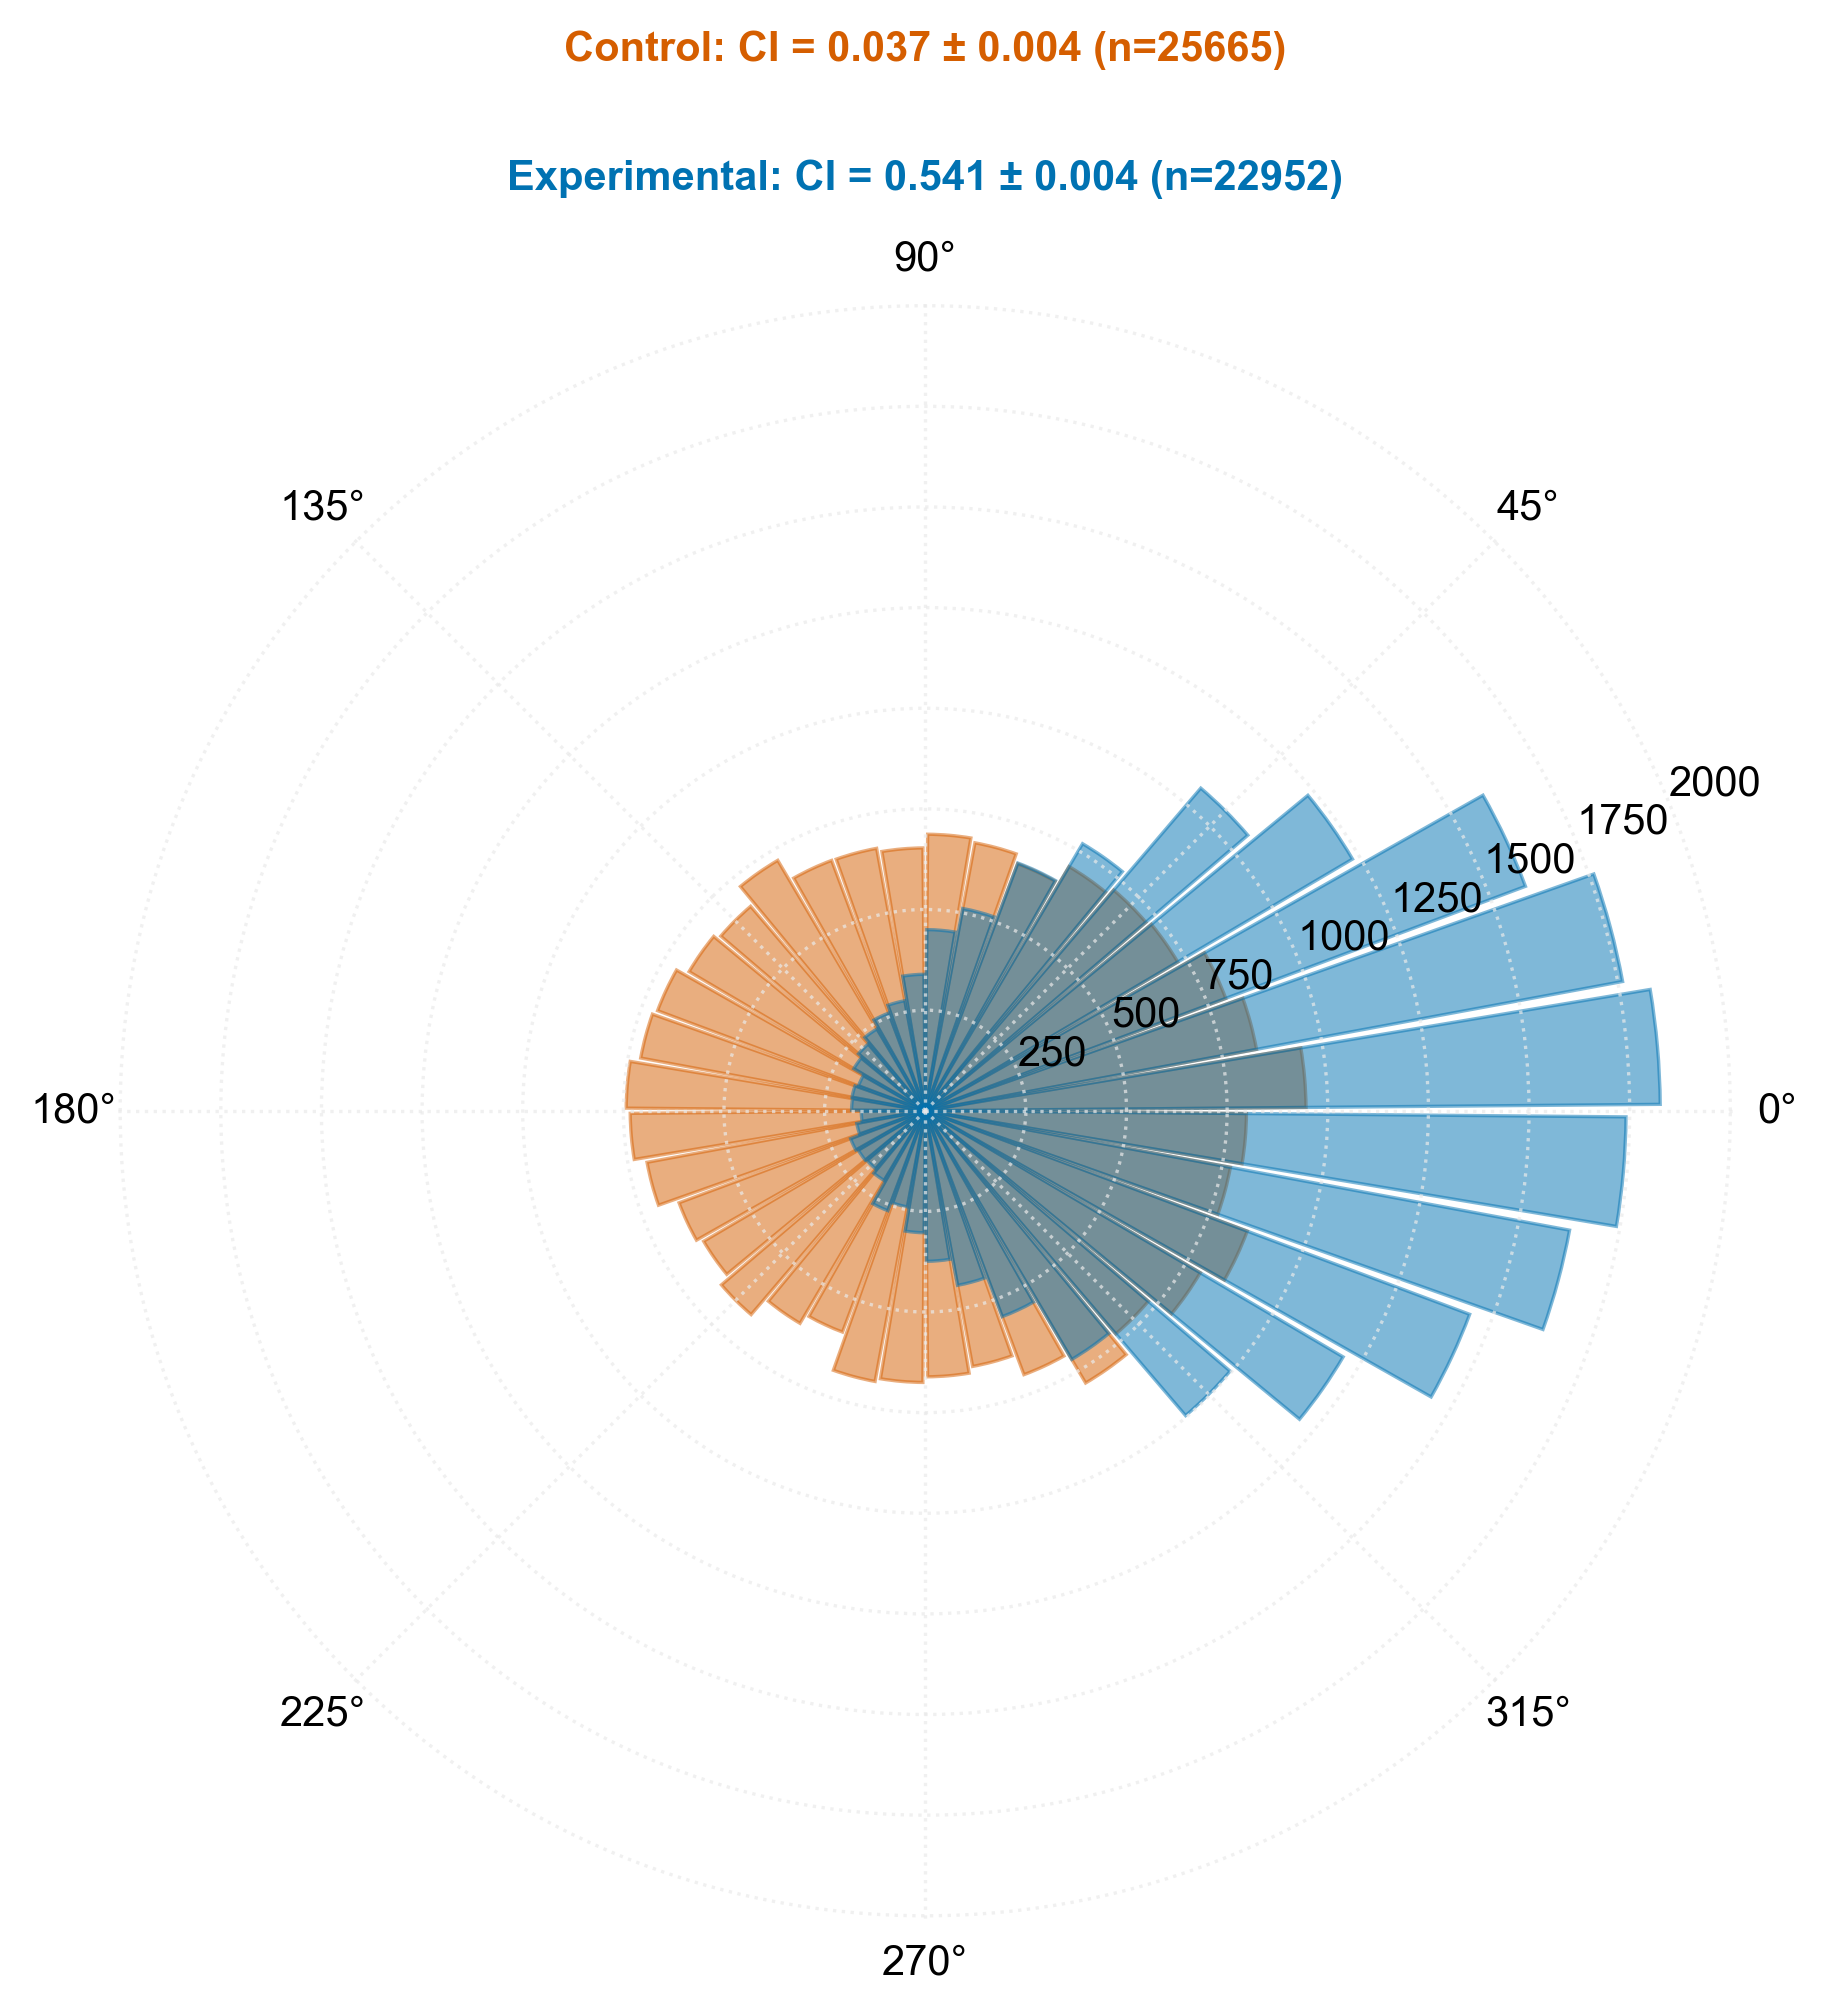

C:\Users\dell\AppData\Local\Temp\ipykernel_20600\3562973164.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=all_fmi_df, x='Group', y='FMI', palette=palette, inner=None, alpha=0.2, linewidth=0)


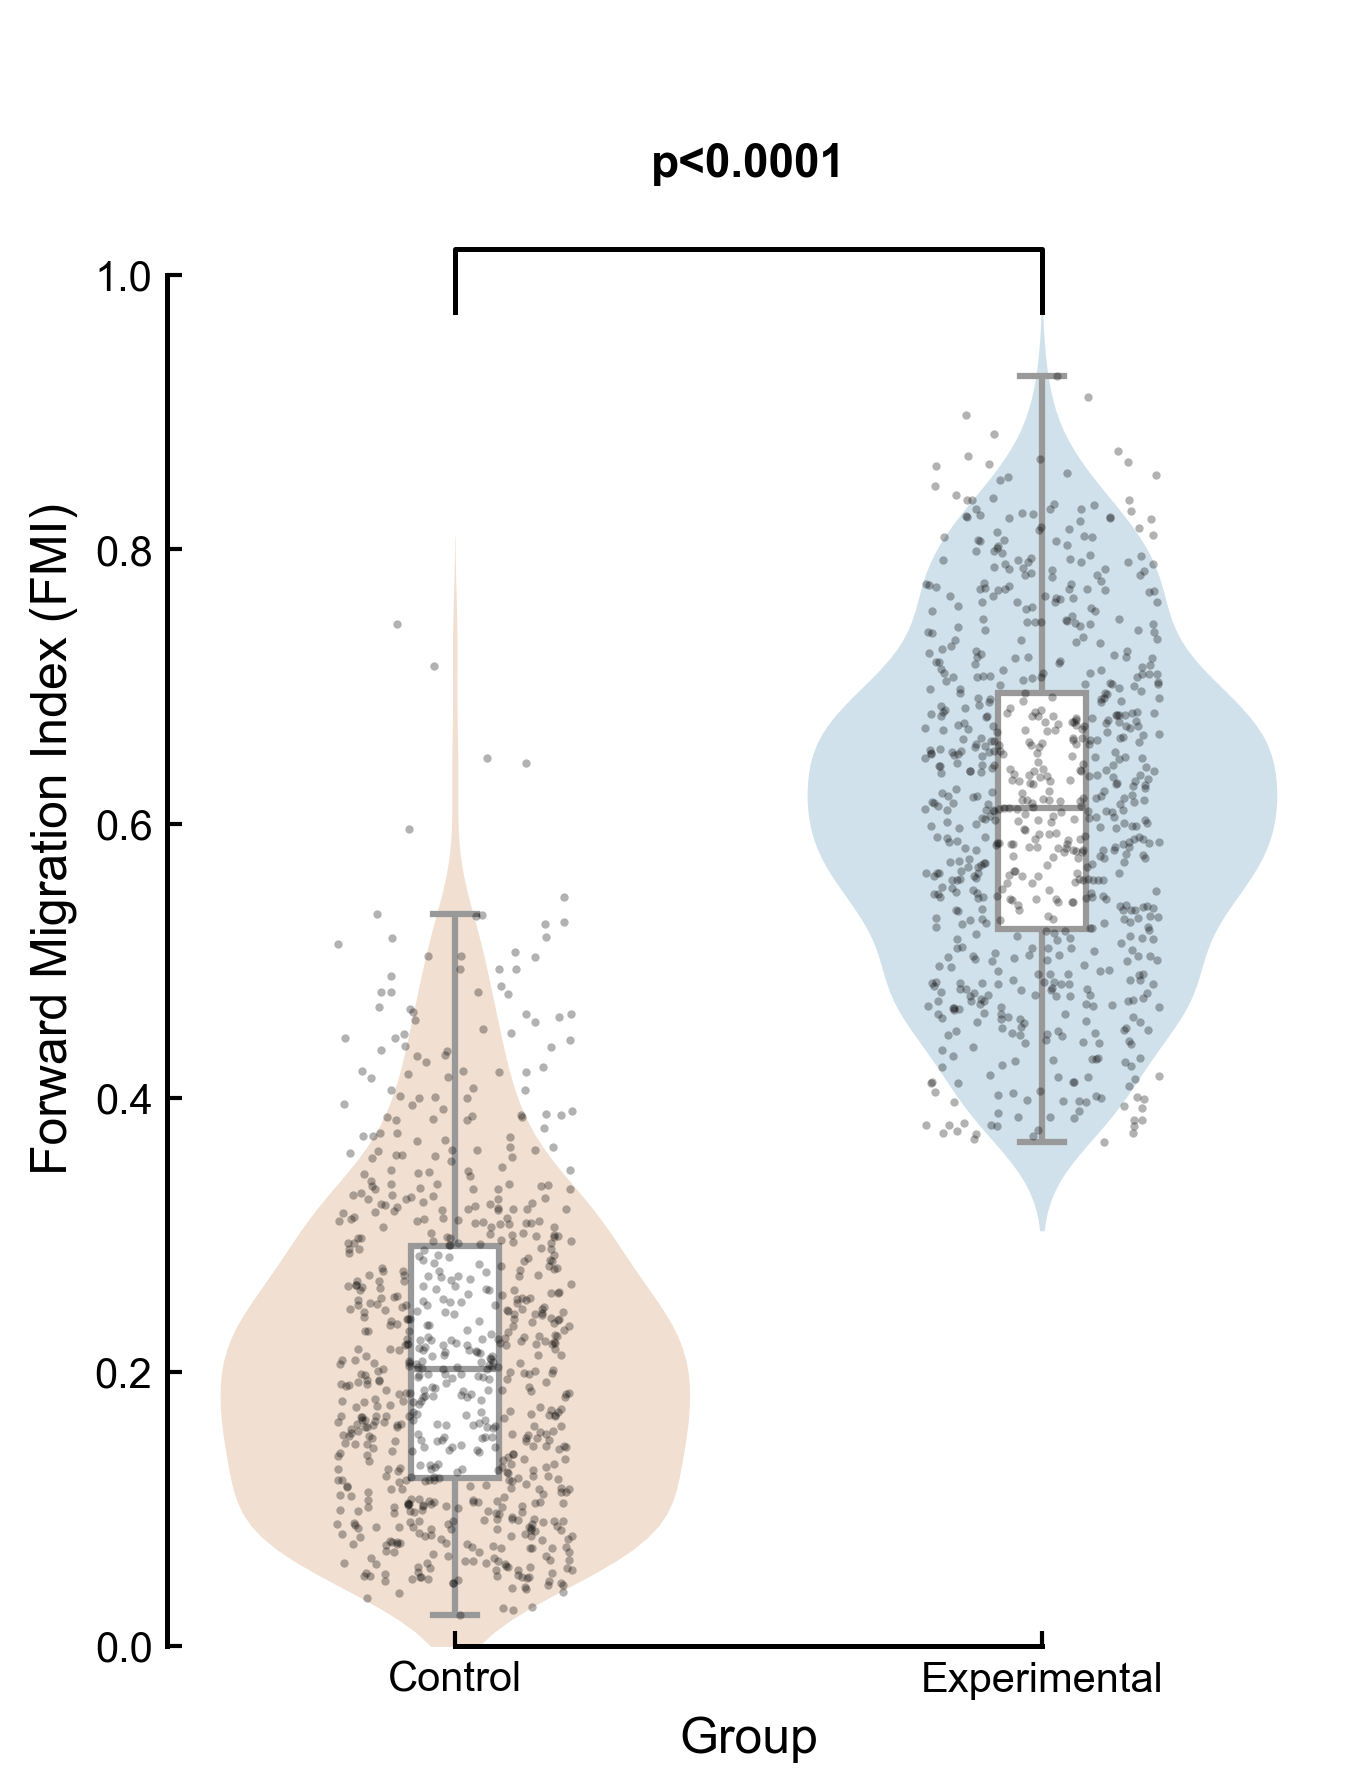

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# ==========================================
# 1. Configuration & Global Settings
# ==========================================
CONFIG = {
    'font_family': 'Arial',
    'save_format': ['svg', 'png'],
    'dpi': 300,
    'colors': {
        'exp': '#D55E00',   
        'ctrl': '#0072B2',  
        'box': '#333333',
        'grid': '#EAEAEA'
    },
    'bins': 36,  
    'default_min_spots': 5,      
    'default_sample_ratio': 1.0  
}

plt.rcParams['font.family'] = CONFIG['font_family']
plt.rcParams['svg.fonttype'] = 'none'

# ==========================================
# 2. Data Processing Modules
# ==========================================

def load_csv_auto(filepath):
    """Automated CSV reader for TrackMate files."""
    try:
        df = pd.read_csv(filepath, header=0)
        test_col = 'LABEL' if 'LABEL' in df.columns else 'Label'
        if test_col not in df.columns:
            df = pd.read_csv(filepath, header=3)
        df.columns = [str(c).upper().strip() for c in df.columns]
        return df
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def calculate_angles_and_ci(files_dict):
    """Calculates segment angles and CI with error ranges."""
    spots_df = load_csv_auto(files_dict['spots'])
    edges_df = load_csv_auto(files_dict['edges'])
    
    if spots_df is None or edges_df is None:
        return None, None

    spot_map = spots_df.set_index('LABEL')[['POSITION_X', 'POSITION_Y']].to_dict('index')
    
    angles, cos_thetas = [], []
    for _, row in edges_df.iterrows():
        edge_label = str(row['LABEL'])
        for sep in ['_', '→', '->']:
            if sep in edge_label:
                parts = edge_label.split(sep)
                break
        else: continue
            
        if len(parts) < 2: continue
        s_id, t_id = parts[0].strip(), parts[1].strip()

        if s_id in spot_map and t_id in spot_map:
            dx = spot_map[t_id]['POSITION_X'] - spot_map[s_id]['POSITION_X']
            dy = spot_map[t_id]['POSITION_Y'] - spot_map[s_id]['POSITION_Y']
            dist = np.sqrt(dx**2 + dy**2) + 1e-9
            
            angles.append(np.arctan2(dy, dx))
            cos_thetas.append(dx / dist)

    res_df = pd.DataFrame({'angle': angles, 'cos_theta': cos_thetas})
    
    # Random sampling of edges
    ratio = files_dict.get('sampling_ratio', CONFIG['default_sample_ratio'])
    if ratio < 1.0:
        res_df = res_df.sample(frac=ratio).reset_index(drop=True)

    stats_dict = {
        'CI_mean': res_df['cos_theta'].mean(),
        'CI_sem': stats.sem(res_df['cos_theta']), # Standard Error
        'N': len(res_df),
        'name': files_dict.get('label', 'Experiment')
    }
    return res_df, stats_dict

def get_fmi_data(files_dict):
    """Extracts FMI data with track length filtering."""
    tracks_df = load_csv_auto(files_dict['tracks'])
    if tracks_df is None: return None
    
    fmi_col = 'LINEARITY_OF_FORWARD_PROGRESSION'
    spot_col = 'NUMBER_SPOTS'
    
    min_spots = files_dict.get('min_spots', CONFIG['default_min_spots'])
    filtered_df = tracks_df[tracks_df[spot_col] >= min_spots].copy()
    
    return pd.DataFrame({
        'FMI': filtered_df[fmi_col],
        'Group': files_dict.get('label', 'Exp')
    })

# ==========================================
# 3. Visualization Modules
# ==========================================

def plot_rose_diagram(angle_data_list, stats_list, output_name, save_dir):
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='polar')
    ax.set_theta_zero_location('E')
    
    max_count = 0
    for i, (angles, stat) in enumerate(zip(angle_data_list, stats_list)):
        color = CONFIG['colors']['exp'] if i == 0 else CONFIG['colors']['ctrl']
        counts, bin_edges = np.histogram(angles, bins=CONFIG['bins'], range=(-np.pi, np.pi))
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        width = (bin_edges[1] - bin_edges[0])
        max_count = max(max_count, max(counts))
        
        ax.bar(bin_centers, counts, width=width*0.9, bottom=0.0, 
               color=color, alpha=0.5, edgecolor=color, linewidth=0.8, label=stat['name'])
        
        # CI formatted as Mean +/- SEM with 3 decimal places
        y_text = 1.15 - (i * 0.08)
        info_str = f"{stat['name']}: CI = {stat['CI_mean']:.3f} ± {stat['CI_sem']:.3f} (n={stat['N']})"
        ax.text(0.5, y_text, info_str, transform=ax.transAxes, ha='center', 
                weight='bold', color=color, fontsize=10)

    ax.set_ylim(0, max_count * 1.1)
    ax.grid(True, color=CONFIG['colors']['grid'], linestyle=':', alpha=0.7)
    ax.spines['polar'].set_visible(False)
    
    plt.savefig(os.path.join(save_dir, f"{output_name}_Rose.svg"), bbox_inches='tight')
    plt.show()

def plot_fmi_distribution(all_fmi_df, output_name, save_dir):
    plt.figure(figsize=(5, 7))
    groups = all_fmi_df['Group'].unique()
    palette = [CONFIG['colors']['exp'], CONFIG['colors']['ctrl']]
    
    # Base Plot
    sns.violinplot(data=all_fmi_df, x='Group', y='FMI', palette=palette, inner=None, alpha=0.2, linewidth=0)
    sns.boxplot(data=all_fmi_df, x='Group', y='FMI', width=0.15, color='white', linewidth=1.5, showfliers=False)
    sns.stripplot(data=all_fmi_df, x='Group', y='FMI', color='black', size=2, alpha=0.3, jitter=0.2)
    
    # Statistical Hypothesis Testing
    if len(groups) == 2:
        data1 = all_fmi_df[all_fmi_df['Group'] == groups[0]]['FMI']
        data2 = all_fmi_df[all_fmi_df['Group'] == groups[1]]['FMI']
        
        # Independent t-test
        t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)
        
        # Formatting P-value: Scientific notation with 2 significant figures
        p_text = f"p = {p_val:.1e}" 
        
        # Significance annotation
        y_max = all_fmi_df['FMI'].max()
        h = y_max * 0.05
        plt.plot([0, 0, 1, 1], [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h], lw=1.2, c='k')
        plt.text(0.5, y_max + 3*h, "p<0.0001", ha='center', va='bottom', fontsize=11, fontweight='bold')

    sns.despine(trim=True)
    plt.ylabel('Forward Migration Index (FMI)', fontsize=12)
    plt.ylim(0, plt.ylim()[1] * 1.1) # Extra space for p-value
    plt.savefig(os.path.join(save_dir, f"{output_name}_FMI.svg"), bbox_inches='tight')
    plt.show()

# ==========================================
# 4. Execution
# ==========================================

if __name__ == "__main__":
    base_dir = "D:/Research/microfluid_pgl_meg/trackmate_series/"
    
    experiments = [
        {
            'label': 'Control',
            'spots': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_spots.csv'),
            'edges': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_edges.csv'),
            'tracks': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_tracks.csv'),
            'min_spots': 20,
            'sampling_ratio': 0.4
        },
        {
            'label': 'Experimental',
            'spots': os.path.join(base_dir, 'mf_fl1_spots.csv'),
            'edges': os.path.join(base_dir, 'mf_fl1_edges.csv'),
            'tracks': os.path.join(base_dir, 'mf_fl1_tracks.csv'),
            'min_spots': 20,
            'sampling_ratio': 1.0
        }
    ]

    angle_list, stats_list, fmi_dfs = [], [], []

    for exp in experiments:
        df_ang, s_dict = calculate_angles_and_ci(exp)
        if df_ang is not None:
            angle_list.append(df_ang['angle'])
            stats_list.append(s_dict)
            
        df_fmi = get_fmi_data(exp)
        if df_fmi is not None:
            fmi_dfs.append(df_fmi)

    if angle_list: plot_rose_diagram(angle_list, stats_list, "Comparison", base_dir)
    if fmi_dfs: plot_fmi_distribution(pd.concat(fmi_dfs), "Comparison", base_dir)

瞬时速度时间演化云雨图

云雨图 (Raincloud Plot) 架构：

“云” (Violin)：展示每个时间段内速度的概率密度分布。

“雨” (Strip)：展示原始数据点，赋予数据真实感。

“伞” (Boxplot)：核心统计量（中位数、四分位数），提供定量参考。

时间分箱 (Binning)：将 0-200 帧划分为 8 个区间（每 25 帧一个 Bin），使原本连续的时间变为可分组比较的离散阶段。

Processing 10 PGL+0.5 MEG3 Gradient_Evolution...
Data loaded. Valid samples: 7092


C:\Users\dell\AppData\Local\Temp\ipykernel_15784\955770118.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Time_Bin', y='Speed_Real', ax=ax,
C:\Users\dell\AppData\Local\Temp\ipykernel_15784\955770118.py:103: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x='Time_Bin', y='Speed_Real', ax=ax,
C:\Users\dell\AppData\Local\Temp\ipykernel_15784\955770118.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Time_Bin', y='Speed_Real', palette=palette,
C:\Users\dell\AppData\Local\Temp\ipykernel_15784\955770118.py:143: FutureWarning: 

Passing `palet

Figure saved to: D:/Research/microfluid_pgl_meg/trackmate_series\10 PGL+0.5 MEG3 Gradient_Evolution_Velocity_Raincloud.svg


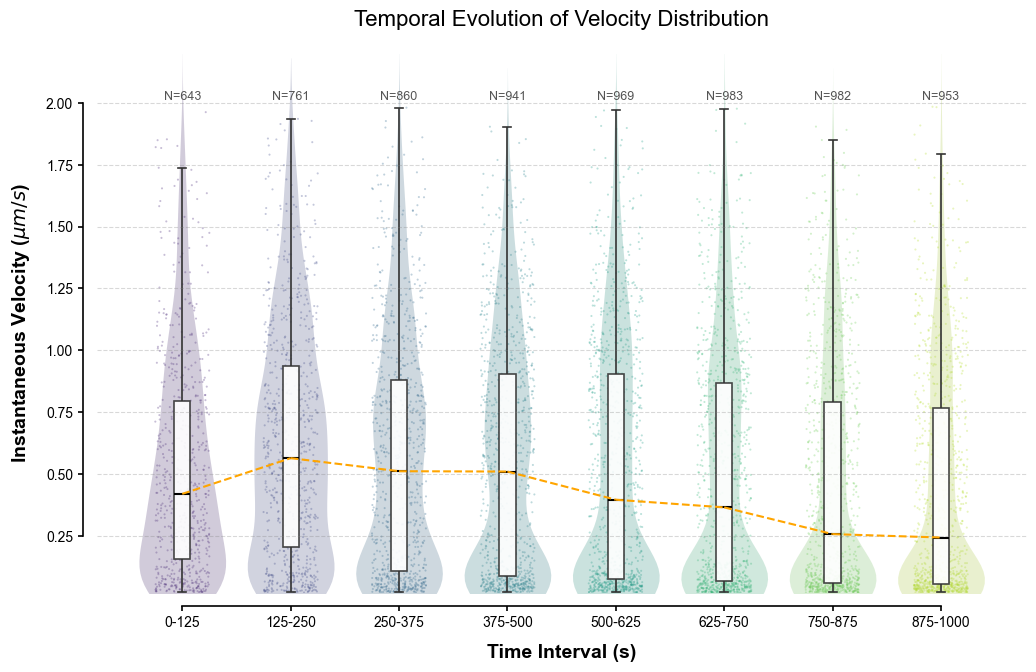

Processing 2.5 PGL+0.5 MEG3 Gradient_Evolution...
Data loaded. Valid samples: 405


C:\Users\dell\AppData\Local\Temp\ipykernel_15784\955770118.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Time_Bin', y='Speed_Real', ax=ax,
C:\Users\dell\AppData\Local\Temp\ipykernel_15784\955770118.py:103: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x='Time_Bin', y='Speed_Real', ax=ax,
C:\Users\dell\AppData\Local\Temp\ipykernel_15784\955770118.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Time_Bin', y='Speed_Real', palette=palette,
C:\Users\dell\AppData\Local\Temp\ipykernel_15784\955770118.py:143: FutureWarning: 

Passing `palet

Figure saved to: D:/Research/microfluid_pgl_meg/trackmate_series\2.5 PGL+0.5 MEG3 Gradient_Evolution_Velocity_Raincloud.svg


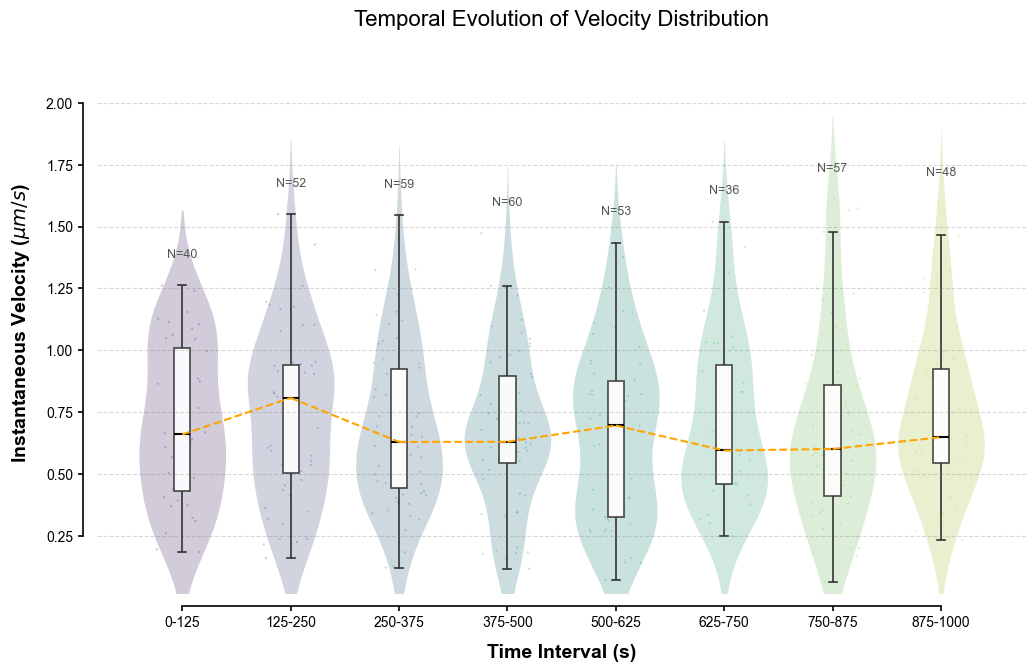

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as ticker

# ==========================================
# 1. 配置参数 (Configuration)
# ==========================================
CONFIG = {
    'time_interval': 5.0,        # 原始帧间隔 (s)
    'speed_factor': 1.0,         # 速度除数 (raw -> um/s)
    'total_time': 1000,          # 总时间范围 (s)
    'n_bins': 8,                 # 分箱数量
    'velocity_range': (0.02, 2.0), # 速度筛选范围 (um/s)
    'font_family': 'Arial',      # 字体
    'save_format': 'svg',        # 保存格式
    'dpi': 300,
    'palette': 'viridis',        # 推荐色系: viridis, mako, rocket
    'point_size': 1.5,           # 散点大小
    'point_alpha': 0.3           # 散点透明度
}

# 全局绘图风格
plt.rcParams['font.family'] = CONFIG['font_family']
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

# ==========================================
# 2. 数据处理模块
# ==========================================

def load_and_process_data(files_dict):
    print(f"Processing {files_dict['name']}...")
    
    # 自动识别 Header
    try:
        df = pd.read_csv(files_dict['edges'], header=0)
        if 'SPEED' not in df.columns: # 尝试旧格式
            df = pd.read_csv(files_dict['edges'], header=3)
        # 统一大写
        df.columns = [str(c).upper().strip() for c in df.columns]
    except Exception as e:
        print(f"Error loading CSV: {e}")
        return None

    # 必需列检查
    if 'EDGE_TIME' not in df.columns or 'SPEED' not in df.columns:
        print("Missing 'EDGE_TIME' or 'SPEED' columns.")
        return None

    # 1. 数据转换
    # 填充 NaN 为 0
    df['SPEED'] = df['SPEED'].fillna(0)
    
    # 转换单位
    # 时间: Frame (0-200) * 5s = Seconds (0-1000)
    df['Time_Sec'] = df['EDGE_TIME'] * CONFIG['time_interval']
    
    # 速度: Raw / 5 = um/s
    df['Speed_Real'] = df['SPEED'] / CONFIG['speed_factor']
    
    # 2. 数据清洗 (Range Filter)
    vmin, vmax = CONFIG['velocity_range']
    df_clean = df[(df['Speed_Real'] >= vmin) & (df['Speed_Real'] <= vmax)].copy()
    
    # 3. 时间分箱 (Binning)
    # 创建 8 个等分区间
    bins = np.linspace(0, CONFIG['total_time'], CONFIG['n_bins'] + 1)
    
    # 生成标签 "0-125", "125-250"...
    labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
    
    # 执行分箱
    df_clean['Time_Bin'] = pd.cut(df_clean['Time_Sec'], bins=bins, labels=labels, include_lowest=True)
    
    # 移除分箱产生的空值（如果原始时间超过1000s）
    df_clean = df_clean.dropna(subset=['Time_Bin'])
    
    print(f"Data loaded. Valid samples: {len(df_clean)}")
    return df_clean

# ==========================================
# 3. 绘图核心：云雨图 (Raincloud Plot)
# ==========================================

def plot_temporal_raincloud(df, output_name, save_dir):
    if df.empty:
        print("No data to plot.")
        return

    # 准备画布
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # 获取唯一的 Bins 和 颜色映射
    unique_bins = df['Time_Bin'].unique().sort_values()
    palette = sns.color_palette(CONFIG['palette'], n_colors=len(unique_bins))
    
    # --- A. 绘制云 (Cloud - Half Violin) ---
    # 使用 seaborn violinplot，后续手动裁剪成一半
    sns.violinplot(data=df, x='Time_Bin', y='Speed_Real', ax=ax,
                   palette=palette, inner=None, linewidth=0, scale='width', saturation=0.85)
    
    # 魔法操作：裁剪 Violin 变成半个
    for item in ax.collections:
        if isinstance(item,  plt.matplotlib.collections.PolyCollection):
            item.set_alpha(0.6) # 设置半透明
            # 获取路径并修改，使其只显示右半边 (如果想竖着看就是右边，这里X轴是Bin，所以是"左/右"半边)
            # 简单的 Hack：由于我们要画 Raincloud，通常 Violins 在左/上，Points 在右/下
            # 这里我们保留 Violin 的左半部分，给右边的散点腾位置
            path = item.get_paths()[0]
            verts = path.vertices
            # 计算中心线
            mean_x = np.mean(verts[:, 0])
            # 裁剪：保留 x < mean_x 的部分 (左半边)
            # 或者利用 set_clip_box 等，但最简单的是利用 transforms
            # 这里我们不做复杂的 path 裁剪，而是通过 offset 散点来实现视觉分离
            # 更好的方法：直接平移 Violin 到左边一点
    
    # 为了美观，我们重新调整 Violin 的宽度和位置太复杂
    # 采用标准叠加法：Violin + Strip + Box
    
    plt.cla() # 清除上面的尝试，用更稳健的叠加层级法

    # 1. 散点图 (Rain) - 底层
    sns.stripplot(data=df, x='Time_Bin', y='Speed_Real', palette=palette, 
                  jitter=0.25, size=CONFIG['point_size'], alpha=CONFIG['point_alpha'], 
                  edgecolor='none', ax=ax, zorder=0)

    # 2. 箱线图 (Umbrella) - 中层
    # 设为极窄，颜色深，作为骨架
    sns.boxplot(data=df, x='Time_Bin', y='Speed_Real', width=0.15,
                boxprops={'facecolor': 'white', 'edgecolor': '#333333', 'alpha': 0.9, 'linewidth': 1.2},
                whiskerprops={'color': '#333333', 'linewidth': 1.2},
                capprops={'color': '#333333', 'linewidth': 1.2},
                medianprops={'color': 'black', 'linewidth': 1.5},
                showfliers=False, ax=ax, zorder=1)

    # 3. 小提琴图 (Cloud) - 顶层 (半透明)
    # 我们画一个完整的 Violin，但是很宽、很透明，覆盖在上面
    v_plot = sns.violinplot(data=df, x='Time_Bin', y='Speed_Real', palette=palette,
                            inner=None, linewidth=0, width=0.8, ax=ax, zorder=0)
    
    # 设置 Violin 透明度，让底下的散点透出来
    for art in v_plot.findobj(plt.matplotlib.collections.PolyCollection):
        art.set_alpha(0.25)

    #用橙色虚线连接相邻bin的median作为趋势线
    # 计算每个 Bin 的中位数
    medians = df.groupby('Time_Bin')['Speed_Real'].median()
    # 连接相邻 Bin 的中位数
    for i in range(len(medians) - 1):
        ax.plot([i, i+1], [medians.iloc[i], medians.iloc[i+1]], 
                color='orange', linestyle='--', linewidth=1.5, zorder=2)

    # --- 装饰与美化 ---
    
    # Y轴设置
    ax.set_ylabel(r'Instantaneous Velocity ($\mu m/s$)', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylim(CONFIG['velocity_range'][0], CONFIG['velocity_range'][1] * 1.1)
    
    # X轴设置
    ax.set_xlabel('Time Interval (s)', fontsize=14, fontweight='bold', labelpad=10)
    plt.xticks(fontsize=11, rotation=0) # 保持水平如果标签不长
    
    # 去除多余边框
    sns.despine(trim=True, offset=10)
    
    # 添加网格线 (仅 Y 轴)
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')
    
    # 添加标题与 N 值
    ax.set_title('Temporal Evolution of Velocity Distribution', fontsize=16, pad=20)
    
    # 在每个 Bin 上方标注样本数 N
    counts = df['Time_Bin'].value_counts().sort_index()
    y_max = df['Speed_Real'].max()
    for i, (label, count) in enumerate(counts.items()):
        # 计算该 Bin 的最大值用于定位
        local_max = df[df['Time_Bin'] == label]['Speed_Real'].max()
        if pd.isna(local_max): local_max = 0
        ax.text(i, min(local_max + 0.1, CONFIG['velocity_range'][1]), f'N={count}', 
                ha='center', va='bottom', fontsize=9, color='#555555')

    # 添加 Colorbar 说明演化趋势 (可选，如果Bin已有颜色)
    # 这里不需要额外的 colorbar，因为 X 轴就是时间

    # 保存
    save_path = os.path.join(save_dir, f"{output_name}_Velocity_Raincloud.{CONFIG['save_format']}")
    plt.savefig(save_path, dpi=CONFIG['dpi'], bbox_inches='tight')
    print(f"Figure saved to: {save_path}")
    plt.show()
# ==========================================
# 4. 主程序
# ==========================================

if __name__ == "__main__":
    base_dir = "D:/Research/microfluid_pgl_meg/trackmate_series"
    
    experiments = [
        #{
            #'name': '0.5 MEG3 Gradient_Evolution_1',
            #'edges': os.path.join(base_dir, 'mf_.5fl_5pgl_edges.csv'),
        #},
        #{
            #'name': '0.5 MEG3 Gradient_Evolution_2',
            #'edges': os.path.join(base_dir, 'mf_fl1_edges.csv'),
        #},
        #{
            #'name': '0.5 MEG3_delta Gradient_Evolution',
            #'edges': os.path.join(base_dir, 'mf_delta_1_edges.csv'),
        #}
        #{
            #'name': 'HMGL-_Control_Gradient',
            #'edges': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_edges.csv'),
        #}
        {
            'name': '10 PGL+0.5 MEG3 Gradient_Evolution',
            'edges': os.path.join(base_dir, 'microfluid_10_edges.csv'),
        },
        {
            'name': '2.5 PGL+0.5 MEG3 Gradient_Evolution',
            'edges': os.path.join(base_dir, '2.5PGL+0.5MEG-3_mf_edges.csv'),
        }
    ]

    # 1. 处理数据
    for experiment in experiments:
        df_result = load_and_process_data(experiment)
    
    # 2. 绘图
        if df_result is not None:
            plot_temporal_raincloud(df_result, experiment['name'], base_dir)


Processing 10 PGL+0.5 MEG3 Gradient_Evolution...
  -> Header detected at row 0 for microfluid_10_spots.csv
  -> Header detected at row 0 for microfluid_10_edges.csv
  -> Successfully processed 7006 valid vectors.


C:\Users\dell\AppData\Local\Temp\ipykernel_15784\2673310484.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Time_Bin', y=col_name, palette=palette,
C:\Users\dell\AppData\Local\Temp\ipykernel_15784\2673310484.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  v_plot = sns.violinplot(data=df, x='Time_Bin', y=col_name, palette=palette,
C:\Users\dell\AppData\Local\Temp\ipykernel_15784\2673310484.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Time_Bin', y=col_name, palette=palette,
C:\Users\dell\AppData\Local\Temp\

Figure saved to: D:/Research/microfluid_pgl_meg/trackmate_series\10 PGL+0.5 MEG3 Gradient_Evolution_Vector_Components.png
Processing 2.5 PGL+0.5 MEG3 Gradient_Evolution...
  -> Header detected at row 0 for 2.5PGL+0.5MEG-3_mf_spots.csv
  -> Header detected at row 0 for 2.5PGL+0.5MEG-3_mf_edges.csv
  -> Successfully processed 403 valid vectors.


C:\Users\dell\AppData\Local\Temp\ipykernel_15784\2673310484.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Time_Bin', y=col_name, palette=palette,
C:\Users\dell\AppData\Local\Temp\ipykernel_15784\2673310484.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  v_plot = sns.violinplot(data=df, x='Time_Bin', y=col_name, palette=palette,
C:\Users\dell\AppData\Local\Temp\ipykernel_15784\2673310484.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Time_Bin', y=col_name, palette=palette,
C:\Users\dell\AppData\Local\Temp\

Figure saved to: D:/Research/microfluid_pgl_meg/trackmate_series\2.5 PGL+0.5 MEG3 Gradient_Evolution_Vector_Components.png


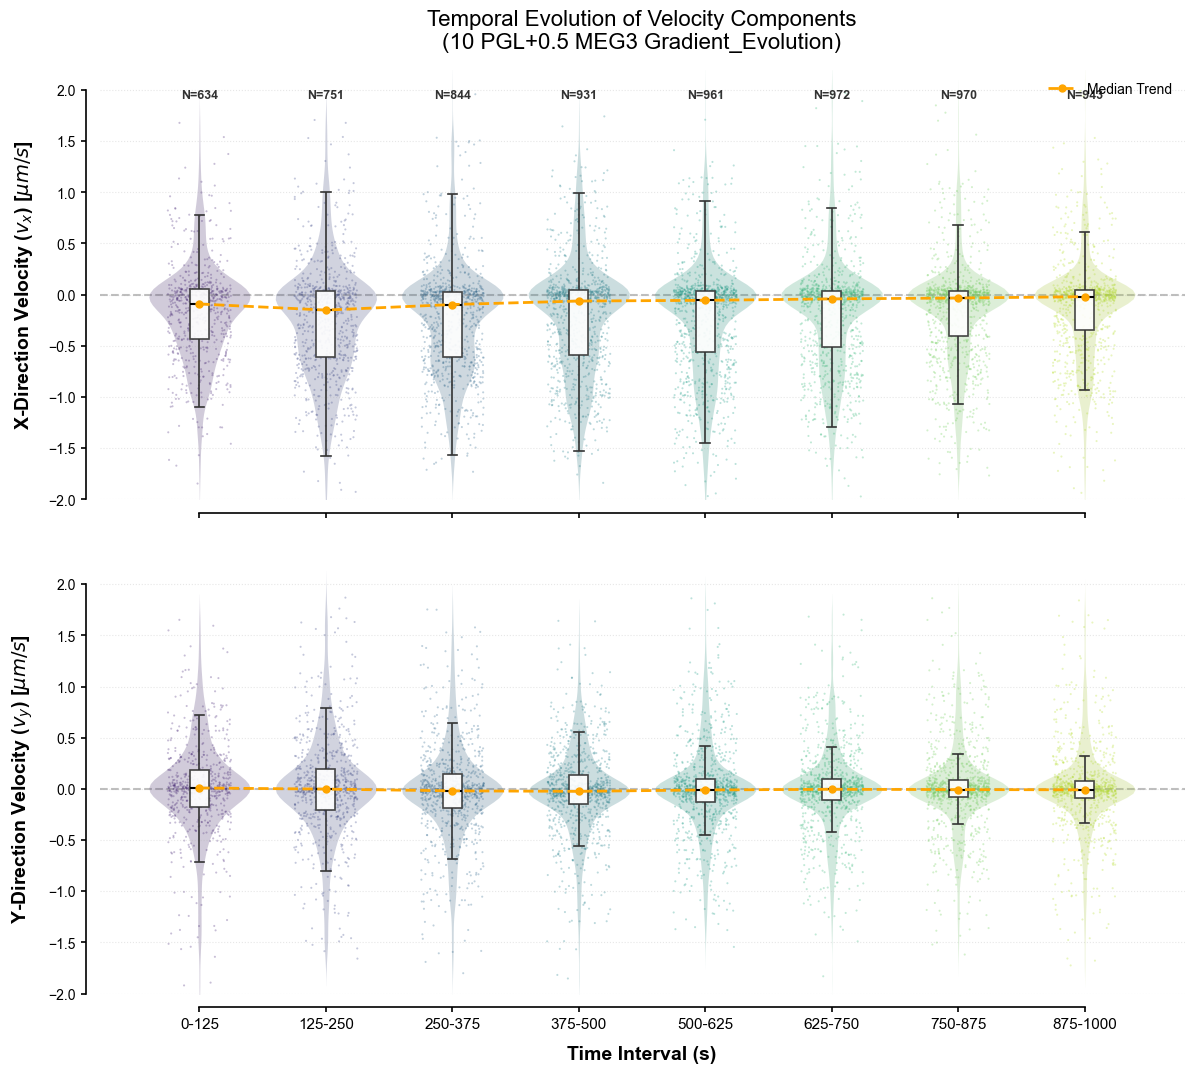

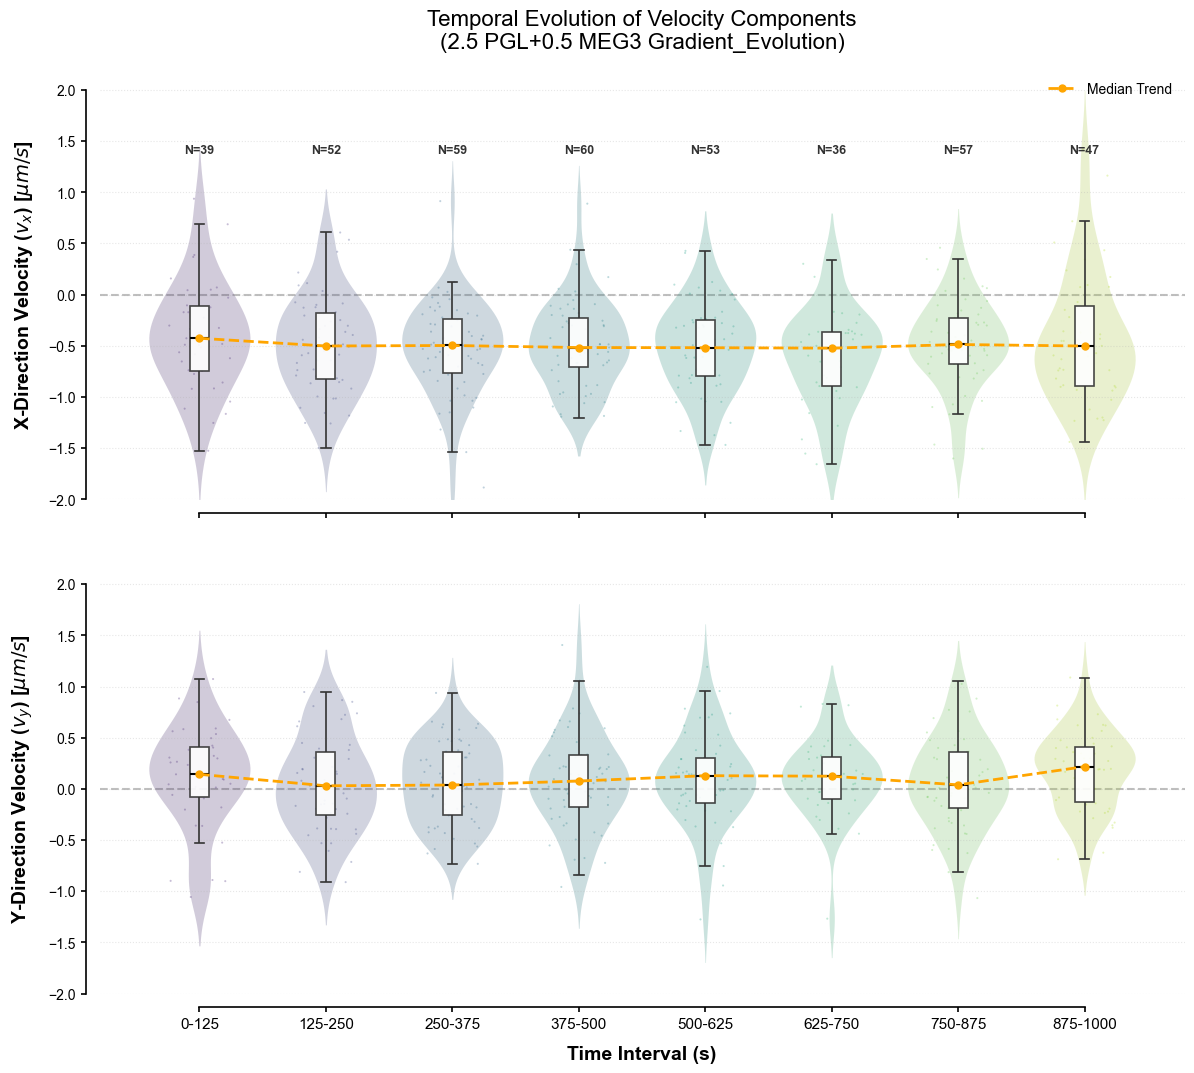

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as ticker

# ==========================================
# 1. 配置参数 (Configuration)
# ==========================================
CONFIG = {
    'time_interval': 5.0,        # 原始帧间隔 (s)
    'speed_factor': 5.0,         # 速度计算的时间除数 (s)
    'total_time': 1000,          # 总时间范围 (s)
    'n_bins': 8,                 # 分箱数量
    'speed_magnitude_range': (0.02, 2.0), # 速度大小筛选范围 (用于剔除噪点)
    'font_family': 'Arial',      # 字体
    'save_format': 'png',        # 保存格式
    'dpi': 600,
    'palette': 'viridis',        # 推荐色系
    'point_size': 1.5,           # 散点大小
    'point_alpha': 0.3,           # 散点透明度
    'velocity_range': (-2.0, 2.0), # 速度筛选范围 (um/s)
}

# 全局绘图风格
plt.rcParams['font.family'] = CONFIG['font_family']
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

# ==========================================
# 2. 数据处理模块 (核心逻辑升级)
# ==========================================

def smart_read_csv(file_path, required_keyword):
    """
    智能读取 CSV 函数：
    自动尝试前 4 行寻找表头，并统一列名格式。
    """
    if not os.path.exists(file_path):
        print(f"Error: File not found -> {file_path}")
        return None

    potential_headers = [0, 1, 2, 3] # 尝试第 0, 1, 2, 3 行作为表头
    
    for h in potential_headers:
        try:
            df = pd.read_csv(file_path, header=h)
            # 清洗列名：转大写，去空格
            clean_columns = [str(c).upper().strip() for c in df.columns]
            
            # 检查关键列是否存在
            if required_keyword.upper() in clean_columns:
                df.columns = clean_columns
                print(f"  -> Header detected at row {h} for {os.path.basename(file_path)}")
                return df
        except Exception:
            continue
            
    print(f"Error: Could not find column '{required_keyword}' in {os.path.basename(file_path)}.")
    return None

def load_and_process_vector_data(files_dict):
    """
    通过 Merge 操作精确关联 Spots 和 Edges，计算矢量速度。
    """
    exp_name = files_dict['name']
    edges_path = files_dict['edges']
    spots_path = edges_path.replace('edges.csv', 'spots.csv') # 自动推断文件名
    
    print(f"Processing {exp_name}...")

    # 1. 读取并清洗 Spots 数据
    df_spots = smart_read_csv(spots_path, 'ID')
    if df_spots is None: return None
    
    # 提取需要的列并去重，防止 ID 重复导致 merge 膨胀
    if df_spots['ID'].duplicated().any():
        print("  Warning: Duplicate IDs found in spots file. Dropping duplicates.")
        df_spots = df_spots.drop_duplicates(subset=['ID'])
        
    spots_subset = df_spots[['ID', 'POSITION_X', 'POSITION_Y']].copy()
    # 强制转换 ID 为整数，确保匹配准确
    spots_subset['ID'] = spots_subset['ID'].astype(int) 

    # 2. 读取并清洗 Edges 数据
    df_edges = smart_read_csv(edges_path, 'SPOT_SOURCE_ID')
    if df_edges is None: return None
    
    required_cols = ['SPOT_SOURCE_ID', 'SPOT_TARGET_ID', 'EDGE_TIME']
    if not all(col in df_edges.columns for col in required_cols):
        print(f"  Error: Edges file missing columns. Found: {df_edges.columns}")
        return None
        
    # 强制转换关联 ID 为整数
    df_edges['SPOT_SOURCE_ID'] = df_edges['SPOT_SOURCE_ID'].astype(int)
    df_edges['SPOT_TARGET_ID'] = df_edges['SPOT_TARGET_ID'].astype(int)

    # 3. 数据融合 (Merge) - 这是最关键的一步
    # 第一次 Merge: 获取起点坐标 (Source Spot)
    # inner join 确保只有当起点在 spots 文件中存在时才保留该边
    merged_df = pd.merge(
        df_edges, 
        spots_subset, 
        left_on='SPOT_SOURCE_ID', 
        right_on='ID', 
        how='inner'
    )
    # 重命名列：POSITION_X -> SRC_X
    merged_df.rename(columns={'POSITION_X': 'SRC_X', 'POSITION_Y': 'SRC_Y'}, inplace=True)
    # 删除多余的 ID 列 (来自 spots 表)
    merged_df.drop(columns=['ID'], inplace=True)

    # 第二次 Merge: 获取终点坐标 (Target Spot)
    merged_df = pd.merge(
        merged_df, 
        spots_subset, 
        left_on='SPOT_TARGET_ID', 
        right_on='ID', 
        how='inner'
    )
    # 重命名列：POSITION_X -> TGT_X
    merged_df.rename(columns={'POSITION_X': 'TGT_X', 'POSITION_Y': 'TGT_Y'}, inplace=True)
    merged_df.drop(columns=['ID'], inplace=True)

    if merged_df.empty:
        print("  Error: No valid links found between Edges and Spots. Check ID consistency.")
        return None

    # 4. 矢量计算
    # 直接使用列运算，无需循环
    merged_df['Dx'] = merged_df['TGT_X'] - merged_df['SRC_X']
    merged_df['Dy'] = merged_df['TGT_Y'] - merged_df['SRC_Y']
    
    merged_df['Vx'] = merged_df['Dx'] / CONFIG['speed_factor']
    merged_df['Vy'] = merged_df['Dy'] / CONFIG['speed_factor']
    merged_df['Speed_Mag'] = np.sqrt(merged_df['Vx']**2 + merged_df['Vy']**2)
    
    # 5. 筛选与分箱
    vmin, vmax = CONFIG['speed_magnitude_range']
    df_clean = merged_df[(merged_df['Speed_Mag'] >= vmin) & (merged_df['Speed_Mag'] <= vmax)].copy()
    
    if df_clean.empty:
        print(f"  Warning: All data filtered out by speed range ({vmin}-{vmax}).")
        return None

    # 时间计算
    df_clean['Time_Sec'] = df_clean['EDGE_TIME'] * CONFIG['time_interval']
    
    # 建立时间分箱
    bins = np.linspace(0, CONFIG['total_time'], CONFIG['n_bins'] + 1)
    labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
    
    df_clean['Time_Bin'] = pd.cut(df_clean['Time_Sec'], bins=bins, labels=labels, include_lowest=True)
    df_clean = df_clean.dropna(subset=['Time_Bin'])
    
    print(f"  -> Successfully processed {len(df_clean)} valid vectors.")
    return df_clean

# ==========================================
# 3. 绘图核心：分量云雨图 (Component Raincloud)
# ==========================================

def plot_component_raincloud(df, output_name, save_dir):
    if df.empty: return

    # 准备画布：2行1列 (上图 Vx, 下图 Vy)
    fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    plt.subplots_adjust(hspace=0.15) # 调整子图间距
    
    unique_bins = df['Time_Bin'].unique().sort_values()
    palette = sns.color_palette(CONFIG['palette'], n_colors=len(unique_bins))
    
    components = [('Vx', 'X-Direction Velocity ($v_x$)'), 
                  ('Vy', 'Y-Direction Velocity ($v_y$)')]

    for i, (col_name, label_text) in enumerate(components):
        ax = axes[i]
        
        # --- 0. 绘制零线 (Zero Line) ---
        ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, zorder=0)

        # --- A. 散点图 (Rain) ---
        sns.stripplot(data=df, x='Time_Bin', y=col_name, palette=palette, 
                      jitter=0.25, size=CONFIG['point_size'], alpha=CONFIG['point_alpha'], 
                      edgecolor='none', ax=ax, zorder=1)

        # --- B. 箱线图 (Umbrella) ---
        sns.boxplot(data=df, x='Time_Bin', y=col_name, width=0.15,
                    boxprops={'facecolor': 'white', 'edgecolor': '#333333', 'alpha': 0.9, 'linewidth': 1.2},
                    whiskerprops={'color': '#333333', 'linewidth': 1.2},
                    capprops={'color': '#333333', 'linewidth': 1.2},
                    medianprops={'color': 'black', 'linewidth': 1.5},
                    showfliers=False, ax=ax, zorder=2)

        # --- C. 小提琴图 (Cloud) ---
        v_plot = sns.violinplot(data=df, x='Time_Bin', y=col_name, palette=palette,
                                inner=None, linewidth=0, width=0.8, ax=ax, zorder=1)
        for art in v_plot.findobj(plt.matplotlib.collections.PolyCollection):
            art.set_alpha(0.25)

        # --- D. 趋势线 (Trend Line) ---
        medians = df.groupby('Time_Bin', observed=True)[col_name].median()
        if not medians.empty:
            # 匹配 bin 顺序
            valid_medians = [medians[b] for b in unique_bins if b in medians.index]
            valid_x = [j for j, b in enumerate(unique_bins) if b in medians.index]
            
            ax.plot(valid_x, valid_medians, color='orange', linestyle='--', linewidth=2.0, marker='o', 
                    markersize=5, zorder=3, label='Median Trend')
            
        # --- E. Y轴设置 ---
        ax.set_ylabel(label_text + r' [$\mu m/s$]', fontsize=14, fontweight='bold', labelpad=10)
        ax.set_ylim(CONFIG['velocity_range'][0], CONFIG['velocity_range'][1] * 1.1)

        # --- 装饰 ---
        ax.set_ylabel(label_text + r' [$\mu m/s$]', fontsize=14, fontweight='bold', labelpad=10)
        ax.grid(axis='y', linestyle=':', alpha=0.3)
        ax.set_xlabel('')
        
        # 统计 N 值
        if i == 0:
            counts = df['Time_Bin'].value_counts()
            y_max = df[col_name].max()
            for idx, bin_label in enumerate(unique_bins):
                if bin_label in counts:
                    ax.text(idx, y_max * 0.95, f'N={counts[bin_label]}', 
                            ha='center', va='bottom', fontsize=9, color='#333333', fontweight='bold')
            ax.legend(loc='upper right', frameon=False)
            ax.set_title(f'Temporal Evolution of Velocity Components\n({output_name})', fontsize=16, pad=15)

    # X 轴设置
    axes[-1].set_xlabel('Time Interval (s)', fontsize=14, fontweight='bold', labelpad=10)
    axes[-1].tick_params(axis='x', labelsize=11)

    
    sns.despine(fig=fig, trim=True, offset=10)
    
    # 保存
    save_path = os.path.join(save_dir, f"{output_name}_Vector_Components.{CONFIG['save_format']}")
    plt.savefig(save_path, dpi=CONFIG['dpi'], bbox_inches='tight')
    print(f"Figure saved to: {save_path}")


# ==========================================
# 4. 主程序
# ==========================================

if __name__ == "__main__":
    # 请确保您的 base_dir 下同时存在 _edges.csv 和 _spots.csv 文件
    # 例如: 'mf_.5fl_5pgl_edges.csv' 和 'mf_.5fl_5pgl_spots.csv'
    base_dir = "D:/Research/microfluid_pgl_meg/trackmate_series"
    
    experiments = [
        #{
            #'name': '0.5 MEG3 Gradient_Evolution_1',
            #'edges': os.path.join(base_dir, 'mf_.5fl_5pgl_edges.csv'),
            #'spots': os.path.join(base_dir, 'mf_.5fl_5pgl_spots.csv')
        #},
        #{
            #'name': '0.5 MEG3 Gradient_Evolution_2',
            #'edges': os.path.join(base_dir, 'mf_fl1_edges.csv'),
            #'spots': os.path.join(base_dir, 'mf_fl1_spots.csv')
        #},
        #{
            #'name': '0.5 MEG3_delta Gradient_Evolution',
            #'edges': os.path.join(base_dir, 'mf_delta_1_edges.csv'),
            #'spots': os.path.join(base_dir, 'mf_delta_1_spots.csv')
        #},
        #{
            #'name': 'HMGL-_Control_Gradient',
            #'spots': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_spots.csv'),
            #'edges': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_edges.csv'),
            #'tracks': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_tracks.csv') # 目前主要用spots和edges
        #},
        {
            'name': '10 PGL+0.5 MEG3 Gradient_Evolution',
            'edges': os.path.join(base_dir, 'microfluid_10_edges.csv'),
            'spots': os.path.join(base_dir, 'microfluid_10_spots.csv'),
            'tracks': os.path.join(base_dir, 'microfluid_10_tracks.csv')
        },
        {
            'name': '2.5 PGL+0.5 MEG3 Gradient_Evolution',
            'edges': os.path.join(base_dir, '2.5PGL+0.5MEG-3_mf_edges.csv'),
            'spots': os.path.join(base_dir, '2.5PGL+0.5MEG-3_mf_spots.csv'),
            'tracks': os.path.join(base_dir, '2.5PGL+0.5MEG-3_mf_tracks.csv')
        }
    ]


    # 1. 处理数据并绘图
    for experiment in experiments:
        # 注意：这里会自动去寻找同目录下的 spots.csv 文件
        df_result = load_and_process_vector_data(experiment)
        
        if df_result is not None:
            plot_component_raincloud(df_result, experiment['name'], base_dir)

下面按照之前的方案绘制MSD分析的图表。

形式：双对数坐标系 ($\log-\log$ Plot)。X轴为 $\Delta t$，Y轴为 MSD。

内容：绘制曲线并进行幂律拟合 $MSD \propto \tau^\alpha$。

MSD分析采用系综平均的方法，先对每一条轨迹单独计算时间平均MSD (tMSD)，然后将所有轨迹的tMSD曲线进行系综平均（取平均值），最后对这条总的平均曲线拟合得到指数 $\alpha$
对每条轨迹，处在相同轨迹中的点spots文件的TRACK_ID列中是相同的。
起始点是POSITION_T一列数值最小的点，结束点是POSITION_T一列数值最大的点。
以POSITION_T为排序的参考可以得到这条TRACK所有点的有序序列。
对每条轨迹分别计算每个点相较起始点的位移平方和(坐标在POSITION_X和POSITION_Y列)和时间差(POSITION_T列与起始点的差值)
即得到该轨迹的tMSD数据。
以合理的方式进行系综平均，得到该组实验中所有轨迹的平均MSD曲线并对其进行幂律拟合，得到指数 $\alpha$。

精心设计布局和配色方案保证高度美观协调，可拓展性强（能够在此基础上方便的加上对照组和其他实验条件的结果），对于表格中的NaN以0代替。POSITION_T列的数据均乘以5，单位转换为秒。
POSITION_X和POSITION_Y列的数据单位为微米。


方法 A：系综平均 MSD (Ensemble-averaged MSD, eMSD)这对应于你提到的“对每个时间间隔下的 edge 做并”。

计算方式： 设定一个绝对时间点 $t$（例如实验开始后的第 10 秒），选取该时刻所有存在的粒子，计算它们在 $t$ 到 $t+\tau$ 之间的位移，然后取平均。公式：$$\langle r^2(\tau) \rangle = \frac{1}{N} \sum_{i=1}^{N} [r_i(t+\tau) - r_i(t)]^2$$

适用场景：系统是非稳态的（Non-stationary），例如粒子性质随时间老化。你需要研究所有粒子在特定时刻的集体行为。

缺点： 需要极大的粒子数量 $N$ 才能获得光滑的曲线。

--- Processing MEG-3 Gradient ---
Calculating MSD for 515 tracks...
Fitted Alpha: 1.5811
Figure saved to: D:/Research/microfluid_pgl_meg/trackmate_series\MEG-3 Gradient_MSD_Nature.svg
--- Processing HMGL-_Control_Gradient ---
Calculating MSD for 4700 tracks...
Fitted Alpha: 0.8207
Figure saved to: D:/Research/microfluid_pgl_meg/trackmate_series\HMGL-_Control_Gradient_MSD_Nature.svg


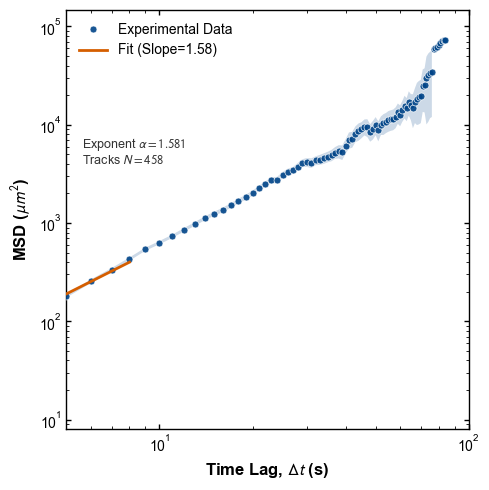

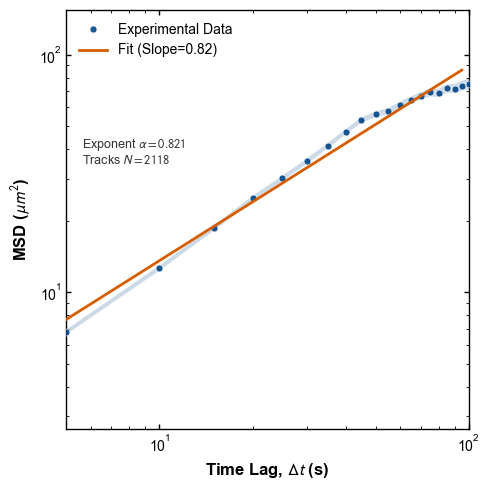

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import os
import matplotlib.ticker as ticker

# ==========================================
# 1. 配置参数 (Configuration)
# ==========================================
CONFIG = {
    'time_interval': 1.0,        # 原始时间间隔 (帧间隔) -> 需乘以该值转换为秒
    'pixel_size': 1.0,           # 坐标单位转换 (假设已经是微米设为1)
    'min_track_len': 10,         # 忽略过短的轨迹
    'font_family': 'Arial',      # 字体 (Nature 推荐 Arial 或 Helvetica)
    'save_format': 'svg',        # 保存格式 (svg/pdf 适合矢量编辑)
    'dpi': 600,                  # 高 DPI
    
    # --- 拟合设置 ---
    'fit_range': 0.1,            # 拟合前 80% 的数据点
    
    # --- 作图范围设置 (Nature 风格建议手动固定范围以保持多图一致) ---
    # 格式: (最小值, 最大值) 或者 None (自动)
    # 如果设为 None，程序会根据数据自动计算，但建议为了美观手动指定 Log 坐标下的范围
    'x_limit': (5, 100),     # 例如: (1, 1000)
    'y_limit': (None, None),     # 例如: (0.01, 100)
    
    # --- 视觉微调 ---
    'colors': {
        'data': '#004488',       # 深蓝 (数据点)
        'fit': '#D55E00',        # 朱红 (拟合线)
        'guide': '#BBBBBB',      # 浅灰 (参考线，更淡一些以不抢眼)
        'fill': '#004488'        # 误差带颜色
    }
}

# 全局绘图风格
plt.rcParams['font.family'] = CONFIG['font_family']
plt.rcParams['axes.linewidth'] = 1.0     # 边框线宽
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.width'] = 0.6
plt.rcParams['ytick.minor.width'] = 0.6
plt.rcParams['xtick.direction'] = 'in'   # 刻度朝内
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['mathtext.fontset'] = 'stixsans' # 数学公式字体匹配

# ==========================================
# 2. 数据处理核心模块 (MSD Calculation)
# ==========================================

def load_track_data(filepath):
    """读取 Spots 文件并进行预处理"""
    try:
        df = pd.read_csv(filepath, header=0)
        # 兼容性检查：如果第一行不是表头，尝试读取可能的旧格式
        if 'TRACK_ID' not in df.columns:
            df = pd.read_csv(filepath, header=3)
        
        df.columns = [str(c).upper().strip() for c in df.columns]
        
        req_cols = ['TRACK_ID', 'POSITION_T', 'POSITION_X', 'POSITION_Y']
        for c in req_cols:
            if c not in df.columns:
                print(f"Error: Missing column {c}")
                return None
        
        df = df.fillna(0)
        
        # 单位转换
        df['Time_Sec'] = df['POSITION_T'] * CONFIG['time_interval']
        df['X_Micron'] = df['POSITION_X'] * CONFIG['pixel_size']
        df['Y_Micron'] = df['POSITION_Y'] * CONFIG['pixel_size']
        
        return df
    except Exception as e:
        print(f"Load Error: {e}")
        return None

def calculate_ensemble_msd(df):
    """计算系综平均 MSD"""
    all_trajectories_data = []
    grouped = df.groupby('TRACK_ID')
    
    print(f"Calculating MSD for {len(grouped)} tracks...")

    for track_id, group in grouped:
        if len(group) < CONFIG['min_track_len']:
            continue
            
        track = group.sort_values('POSITION_T')
        
        start_point = track.iloc[0]
        x0 = start_point['X_Micron']
        y0 = start_point['Y_Micron']
        t0 = start_point['Time_Sec']
        
        xs = track['X_Micron'].values
        ys = track['Y_Micron'].values
        ts = track['Time_Sec'].values
        
        dt = ts - t0
        sd = (xs - x0)**2 + (ys - y0)**2
        
        track_msd = pd.DataFrame({
            'Delta_T': dt,
            'SD': sd,
            'Track_ID': track_id
        })
        all_trajectories_data.append(track_msd)

    if not all_trajectories_data:
        return None

    full_data = pd.concat(all_trajectories_data, ignore_index=True)
    full_data['Delta_T'] = full_data['Delta_T'].round(3)
    
    msd_summary = full_data.groupby('Delta_T')['SD'].agg(['mean', 'sem', 'count']).reset_index()
    msd_summary.rename(columns={'mean': 'MSD', 'sem': 'SEM', 'count': 'N'}, inplace=True)
    msd_summary = msd_summary[msd_summary['Delta_T'] > 0]
    
    return msd_summary

def fit_power_law(df):
    """幂律拟合: MSD = K * t^alpha"""
    limit_idx = int(len(df) * CONFIG['fit_range'])
    fit_data = df.iloc[:limit_idx]
    
    x_data = fit_data['Delta_T'].values
    y_data = fit_data['MSD'].values
    
    # 避免 log(0)
    mask = (x_data > 0) & (y_data > 0)
    x_data = x_data[mask]
    y_data = y_data[mask]

    if len(x_data) < 2:
        return 0, 0, x_data, y_data

    log_x = np.log10(x_data)
    log_y = np.log10(y_data)
    
    slope, intercept = np.polyfit(log_x, log_y, 1)
    
    alpha = slope
    K = 10**intercept
    
    return alpha, K, x_data, K * (x_data ** alpha)

# ==========================================
# 3. 绘图模块 (Visualization)
# ==========================================

def plot_msd_loglog(msd_df, fit_results, output_name, save_dir):
    """绘制出版级 MSD 图表"""
    alpha, K, fit_x, fit_y = fit_results
    
    # 创建画布 (宽高比 1:1 或 4:3 比较适合 MSD)
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # --- 1. 确定作图范围 (Limits) ---
    # 优先使用配置中的范围，否则根据数据自动计算
    # 自动计算时留出一点边距 (padding)
    x_min = CONFIG['x_limit'][0] if CONFIG['x_limit'][0] else msd_df['Delta_T'].min() * 0.8
    x_max = CONFIG['x_limit'][1] if CONFIG['x_limit'][1] else msd_df['Delta_T'].max() * 1.5
    y_min = CONFIG['y_limit'][0] if CONFIG['y_limit'][0] else msd_df['MSD'].min() * 0.5
    y_max = CONFIG['y_limit'][1] if CONFIG['y_limit'][1] else msd_df['MSD'].max() * 2.0
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # --- 2. 绘制参考线 (Dynamic Guides) ---
    # 根据当前视图范围绘制贯穿的参考线，并放置在数据层之下 (zorder=0)
    
    # 选择一个参考点 (通常取视图中间或左下区域)
    # 这里我们取 x_min 的某个倍数作为起点，保证线在图内
    ref_x_start = x_min * 1.5
    
    # 为了让参考线合适地 positioned，我们需要预估一个截距
    # 简单的做法：让参考线通过数据中间区域的下方，作为“基底”参考
    # 取数据中间点的 y 值，再除以一个系数让参考线沉底
    mid_idx = len(msd_df) // 2
    data_mid_y = msd_df['MSD'].iloc[mid_idx]
    data_mid_x = msd_df['Delta_T'].iloc[mid_idx]
    
    # Guide Alpha = 1 (Diffusive)
    # y = C * x^1 -> C = y / x
    # 我们设定参考线经过点 (data_mid_x, data_mid_y / 5) 左右
    c1 = (data_mid_y / 10) / (data_mid_x**1) 
    guide_x = np.logspace(np.log10(x_min), np.log10(x_max), 100)
    guide_y1 = c1 * guide_x
    
    # Guide Alpha = 2 (Ballistic)
    # y = C * x^2
    c2 = (data_mid_y / 10) / (data_mid_x**2)
    guide_y2 = c2 * (guide_x**2)
    
    # 绘制参考线 (虚线)
    #ax.loglog(guide_x, guide_y1, '--', color=CONFIG['colors']['guide'], linewidth=1.0, zorder=1)
    #ax.loglog(guide_x, guide_y2, '--', color=CONFIG['colors']['guide'], linewidth=1.0, zorder=1)
    
    # 添加参考线文字 (Angle calculation is complex in loglog, so we place text manually near the end)
    # 将文字放在右侧边界附近
    text_x = x_max * 0.6
    text_y1 = c1 * text_x
    text_y2 = c2 * (text_x**2)
    
    # 只有当文字在图表范围内时才显示
    #if y_min < text_y1 < y_max:
        #ax.text(text_x, text_y1, r'$\alpha=1$', fontsize=9, color=CONFIG['colors']['guide'], 
                #ha='right', va='bottom', rotation=45, alpha=0.8)
    #if y_min < text_y2 < y_max:
        #ax.text(text_x, text_y2, r'$\alpha=2$', fontsize=9, color=CONFIG['colors']['guide'], 
                #ha='right', va='bottom', rotation=60, alpha=0.8)

    # --- 3. 绘制误差带和数据 ---
    # 误差带
    ax.fill_between(msd_df['Delta_T'], 
                    msd_df['MSD'] - msd_df['SEM'], 
                    msd_df['MSD'] + msd_df['SEM'], 
                    color=CONFIG['colors']['fill'], alpha=0.2, linewidth=0, zorder=2)
    
    # 数据点
    ax.loglog(msd_df['Delta_T'], msd_df['MSD'], 'o', 
              color=CONFIG['colors']['data'], markersize=5, alpha=0.9, 
              markeredgewidth=0.5, markeredgecolor='white', label='Experimental Data', zorder=3)
    
    # 拟合线
    ax.loglog(fit_x, fit_y, '-', color=CONFIG['colors']['fit'], linewidth=2.0, 
              label=f'Fit (Slope={alpha:.2f})', zorder=4)
    
    # --- 4. 标签与美化 ---
    ax.set_xlabel('Time Lag, $\Delta t$ (s)', fontsize=12, fontweight='bold')
    ax.set_ylabel(r'MSD ($\mu m^2$)', fontsize=12, fontweight='bold')
    
    # 刻度设置
    ax.tick_params(which='both', top=True, right=True, labelsize=10)
    ax.minorticks_on()
    
    # --- 5. 图例与统计信息 (优化布局) ---
    # 将所有信息整合到左上角，这样最整洁
    
    # 创建图例
    legend = ax.legend(frameon=False, fontsize=10, loc='upper left')
    
    # 添加统计信息文本块 (位于图例下方)
    info_text = (f"Exponent $\\alpha = {alpha:.3f}$\n"
                 f"Tracks $N = {msd_df['N'].max()}$\n") # 仅适用于 alpha~1
    
    # 使用 transform=ax.transAxes 相对坐标定位
    # x=0.03, y=0.75 大概在左上角图例的下方
    ax.text(0.04, 0.70, info_text, transform=ax.transAxes, fontsize=9,
            ha='left', va='top', color='#333333',
            bbox=dict(facecolor='white', alpha=0.0, edgecolor='none')) # 无边框，纯文字

    plt.tight_layout()

    # 保存
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    save_path = os.path.join(save_dir, f"{output_name}_MSD_Nature.{CONFIG['save_format']}")
    plt.savefig(save_path, dpi=CONFIG['dpi'], bbox_inches='tight')
    print(f"Figure saved to: {save_path}")
    # plt.show() # 如果在无界面环境运行请注释
# ==========================================
# 4. 主程序入口
# ==========================================

if __name__ == "__main__":
    base_dir =  "D:/Research/microfluid_pgl_meg/trackmate_series"
    
    experiments = [
        {
            'name':'MEG-3 Gradient',
            'spots': os.path.join(base_dir, 'mf_.5fl_5pgl_spots.csv'),
            'edges': os.path.join(base_dir, 'mf_.5fl_5pgl_edges.csv'),
            'tracks': os.path.join(base_dir, 'mf_.5fl_5pgl_tracks.csv')
        },
        {
            'name': 'HMGL-_Control_Gradient',
            'spots': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_spots.csv'),
            'edges': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_edges.csv'),
            'tracks': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_tracks.csv')
        }
    ]
    for exp in experiments:
        print(f"--- Processing {exp['name']} ---")
        
        # 1. 加载
        df_raw = load_track_data(exp['spots'])
        
        if df_raw is not None:
            # 2. 计算 MSD
            msd_result = calculate_ensemble_msd(df_raw)
            
            if msd_result is not None:
                # 3. 拟合
                fit_res = fit_power_law(msd_result)
                print(f"Fitted Alpha: {fit_res[0]:.4f}")
                
                # 4. 绘图
                plot_msd_loglog(msd_result, fit_res, exp['name'], base_dir)
            else:
                print("MSD calculation failed (not enough data?).")

Multiple groups MSD comparison

[*] Processing Group: MEG-3 Gradient
    [Success] Alpha = 1.602, Tracks = 515
[*] Processing Group: HMGL- Control Group
    [Success] Alpha = 0.821, Tracks = 4700
[*] Plot saved to: D:/Research/microfluid_pgl_meg/trackmate_series\MSD_comparative_msd_analysis_20260127_162850.svg


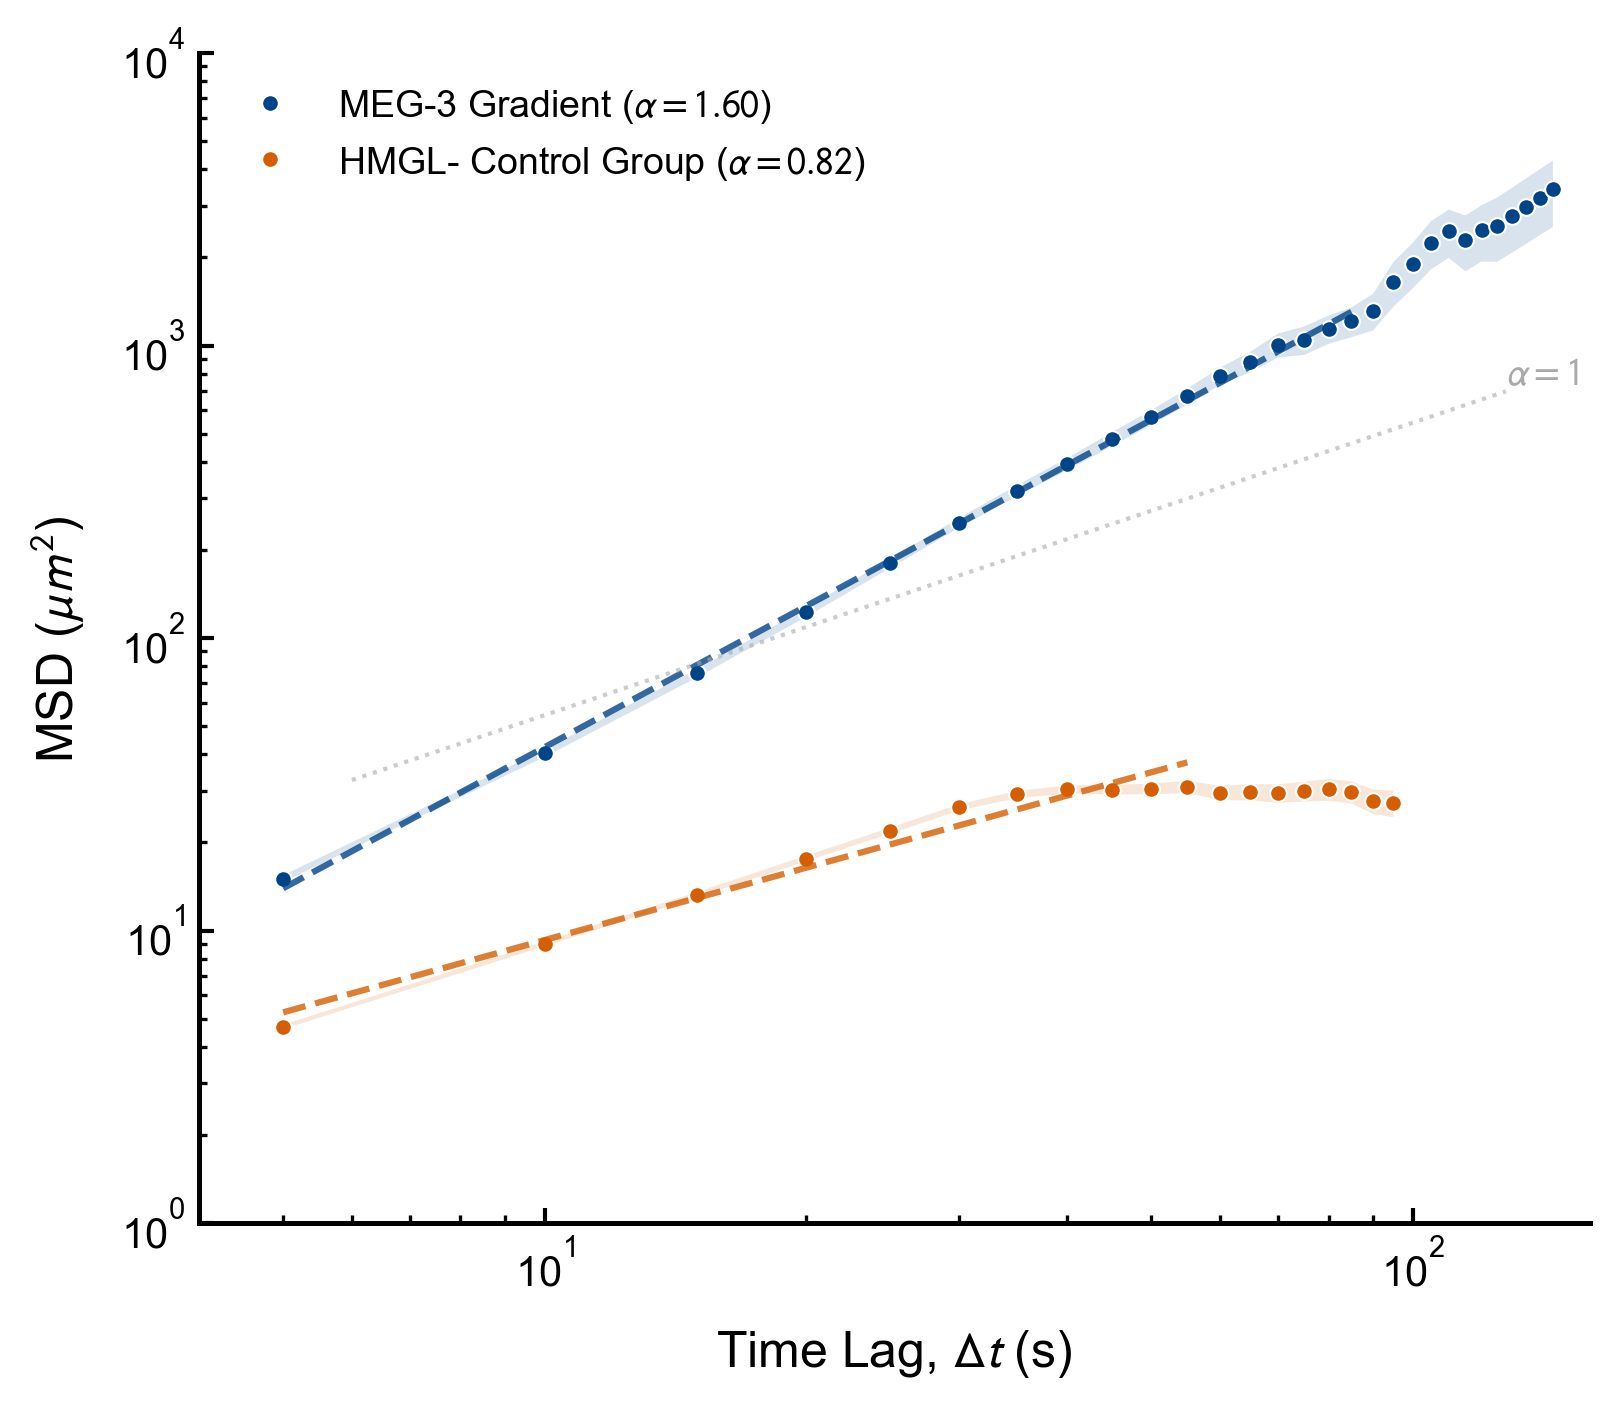

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import os
import time
from datetime import datetime

# ==========================================
# 1. GLOBAL CONFIGURATION (Nature/CNS Style)
# ==========================================
STYLE_CONFIG = {
    'font_family': 'Arial',
    'axes_linewidth': 1.2,
    'tick_width': 1.0,
    'dpi': 600,
    'save_format': 'svg',  # Changed to .svg as requested
    'palette': ['#004488', '#D55E00', '#009E73', '#CC79A7', '#56B4E9'], 
    'alpha_fill': 0.15,
    'fit_range': 0.25,      # Default: use first 25% of data points for power-law fitting
}

# Apply global matplotlib settings
plt.rcParams.update({
    'font.family': STYLE_CONFIG['font_family'],
    'axes.linewidth': STYLE_CONFIG['axes_linewidth'],
    'xtick.major.width': STYLE_CONFIG['tick_width'],
    'ytick.major.width': STYLE_CONFIG['tick_width'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': False,      # Disable top ticks
    'ytick.right': False,    # Disable right ticks
    'mathtext.fontset': 'stixsans', # Use sans-serif math font to match Arial
    'pdf.fonttype': 42,      
    'ps.fonttype': 42
})

class MSDAnalyzer:
    def __init__(self, time_interval=1.0, pixel_size=1.0, min_track_len=10):
        """
        Initialize the analyzer.
        :param time_interval: Time between frames (seconds).
        :param pixel_size: Size of one pixel (microns).
        :param min_track_len: Minimum points required for a valid track.
        """
        self.dt = time_interval
        self.px = pixel_size
        self.min_len = min_track_len
        self.datasets = {} # Stores results for multiple groups

    def load_and_process(self, group_name, filepath, fit_range=None, max_lag_time=None):
        """
        Load TrackMate spots and compute time-lagged MSD for all trajectories.
        """
        print(f"[*] Processing Group: {group_name}")
        current_fit_range = fit_range if fit_range is not None else STYLE_CONFIG['fit_range']
        
        try:
            try:
                df = pd.read_csv(filepath)
                if 'TRACK_ID' not in df.columns:
                    df = pd.read_csv(filepath, skiprows=3)
            except Exception:
                print(f"    [Error] Could not parse {filepath}")
                return False

            df.columns = [str(c).upper().strip() for c in df.columns]
            
            # Unit Conversion
            df['X_UM'] = df['POSITION_X'] * self.px
            df['Y_UM'] = df['POSITION_Y'] * self.px
            time_col = 'FRAME' if 'FRAME' in df.columns else 'POSITION_T'
            df['T_SEC'] = df[time_col] * self.dt

            all_msds = []
            grouped = df.groupby('TRACK_ID')

            for tid, track in grouped:
                if len(track) < self.min_len:
                    continue
                
                track = track.sort_values('T_SEC')
                x = track['X_UM'].values
                y = track['Y_UM'].values
                
                n_points = len(track)
                # Max lag is limited by track length or user-specified max_lag_time
                max_lag_steps = n_points // 2 
                if max_lag_time:
                    max_lag_steps = min(max_lag_steps, int(max_lag_time / self.dt))

                lags = np.arange(1, max_lag_steps)
                
                track_res = []
                for lag in lags:
                    dx = x[lag:] - x[:-lag]
                    dy = y[lag:] - y[:-lag]
                    sq_dist = dx**2 + dy**2
                    track_res.append([lag * self.dt, np.mean(sq_dist)])
                
                all_msds.append(pd.DataFrame(track_res, columns=['tau', 'msd']))

            if not all_msds:
                print(f"    [Warning] No valid tracks found in {group_name}")
                return False

            master_df = pd.concat(all_msds)
            summary = master_df.groupby('tau')['msd'].agg(['mean', 'sem', 'count']).reset_index()
            summary.rename(columns={'mean': 'MSD', 'sem': 'SEM', 'count': 'N'}, inplace=True)
            
            # Fitting: MSD = K * t^alpha
            fit_mask = (summary['tau'] > 0) & (summary['tau'] < summary['tau'].max() * current_fit_range)
            fit_df = summary[fit_mask]
            
            alpha, K = np.nan, np.nan
            fit_curve = None
            if len(fit_df) > 2:
                log_t = np.log10(fit_df['tau'].values)
                log_m = np.log10(fit_df['MSD'].values)
                slope, intercept = np.polyfit(log_t, log_m, 1)
                alpha = slope
                K = 10**intercept
                fit_curve = (fit_df['tau'].values, K * (fit_df['tau'].values ** alpha))

            self.datasets[group_name] = {
                'data': summary,
                'alpha': alpha,
                'fit_curve': fit_curve,
                'n_tracks': len(grouped),
                'max_display_lag': max_lag_time
            }
            print(f"    [Success] Alpha = {alpha:.3f}, Tracks = {len(grouped)}")
            return True

        except Exception as e:
            print(f"    [Critical Error] {e}")
            return False

    def plot_multi_group(self, title="Ensemble MSD Analysis", 
                        x_range=(None, None), y_range=(None, None), 
                        save_dir="."):
        """
        Generate a publication-quality log-log plot for all loaded datasets.
        """
        if not self.datasets:
            print("[Error] No data to plot.")
            return

        fig, ax = plt.subplots(figsize=(5.5, 4.8))
        
        for i, (name, res) in enumerate(self.datasets.items()):
            df = res['data']
            # Apply individual group data limit if specified
            if res['max_display_lag']:
                df = df[df['tau'] <= res['max_display_lag']]
                
            color = STYLE_CONFIG['palette'][i % len(STYLE_CONFIG['palette'])]
            
            # 1. Shaded Error Band (SEM)
            ax.fill_between(df['tau'], df['MSD'] - df['SEM'], df['MSD'] + df['SEM'],
                            color=color, alpha=STYLE_CONFIG['alpha_fill'], edgecolor='none')
            
            # 2. Main Data Line
            ax.loglog(df['tau'], df['MSD'], 'o', color=color, markersize=4, 
                      markeredgewidth=0.5, markeredgecolor='white',
                      label=f"{name} ($\\alpha={res['alpha']:.2f}$)")
            
            # 3. Individual Fit Line (Dashed)
            if res['fit_curve'] is not None:
                fx, fy = res['fit_curve']
                ax.loglog(fx, fy, '--', color=color, linewidth=1.5, alpha=0.8)

        # Reference lines
        self._add_reference_slopes(ax, x_range)

        # Labels and Scaling
        ax.set_xlabel(r'Time Lag, $\Delta t$ (s)', fontsize=12, labelpad=8, fontname='Arial')
        ax.set_ylabel(r'MSD ($\mu m^2$)', fontsize=12, labelpad=8, fontname='Arial')
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)
        
        # Legend
        ax.legend(frameon=False, loc='upper left', fontsize=9)
        
        # Fine-tuning axes: Completely remove top and right spines and ticks
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='both', top=False, right=False, labelsize=10)
        
        plt.tight_layout()

        # Adaptive Filename (Unique Timestamp)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        safe_title = title.replace(" ", "_").lower()
        filename = f"MSD_{safe_title}_{timestamp}.{STYLE_CONFIG['save_format']}"
        save_path = os.path.join(save_dir, filename)
        
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
            
        plt.savefig(save_path, dpi=STYLE_CONFIG['dpi'], bbox_inches='tight')
        print(f"[*] Plot saved to: {save_path}")
        plt.show()

    def _add_reference_slopes(self, ax, x_range):
        """Helper to add alpha=1 guide line."""
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        
        start_x = x_range[0] if x_range[0] else xmin
        end_x = x_range[1] if x_range[1] else xmax
        
        ref_x = np.logspace(np.log10(start_x * 1.5), np.log10(end_x * 0.8), 10)
        
        # Calculate baseline y-position (avoiding log errors)
        y_anchor = ymin * 10 if not (np.isnan(ymin) or ymin <= 0) else 1.0
        ref_y1 = y_anchor * (ref_x / ref_x[0])**1
        
        ax.loglog(ref_x, ref_y1, ':', color='#AAAAAA', linewidth=1.0, alpha=0.6)
        ax.text(ref_x[-1], ref_y1[-1], '$\\alpha=1$', fontsize=9, color='#AAAAAA', 
                va='bottom', ha='left', fontname='Arial')

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    # --- 1. SETUP ---
    analyzer = MSDAnalyzer(
        time_interval = 5.0,   # Seconds per frame
        pixel_size    = 1.0,   # Micron per pixel
        min_track_len = 15    
    )

    base_path = "D:/Research/microfluid_pgl_meg/trackmate_series"
    
    # --- 2. DATA LOADING & INDIVIDUAL RANGES ---
    experiments = [
        {
            'label': 'MEG-3 Gradient',
            'path': os.path.join(base_path, 'mf_.5fl_5pgl_spots.csv'),
            'fit_range': 0.6,       # Use first 20% for fitting
            'max_lag': 150          # Show up to 150s
        },
        {
            'label': 'HMGL- Control Group',
            'path': os.path.join(base_path, 'HMGL-+4.5pgl_flowcell_spots.csv'),
            'fit_range': 0.6,       # Use first 30% for fitting
            'max_lag': 100          # Show up to 100s
        }
    ]

    for exp in experiments:
        if os.path.exists(exp['path']):
            analyzer.load_and_process(
                exp['label'], 
                exp['path'], 
                fit_range=exp.get('fit_range'),
                max_lag_time=exp.get('max_lag')
            )
        else:
            print(f"[Skip] File not found: {exp['path']}")

    # --- 3. VISUALIZATION ---
    analyzer.plot_multi_group(
        title   = "Comparative MSD Analysis",
        x_range = (4, 160),    
        y_range = (1, 10000), 
        save_dir = base_path
    )

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

# ================= Configuration Section (User Configuration) =================
CONFIG = {
    "base_path": r"D:\Research\microfluid_pgl_meg\trackmate_series\size_distribution",
    "conditions": ["2.5PGL", "4.5PGL", "10PGL"],
    
    # Experimental Parameters
    "time_interval": 5.0,        # Seconds per frame
    "bin_size_frames": 5,        # Bin size (frames) for error bar statistics
    "pixel_calibration": 1.0,    # 1.0 if input is already in microns
    
    # Filter and Range Settings (Independent for each condition)
    "frame_ranges": {
        "2.5PGL": (1, 50),
        "4.5PGL": (26, 75),
        "10PGL": (1, 50)
    },
    
    # Direction Correction: Set whether to flip velocity direction (True = multiply by -1)
    # Used to correct coordinate inversion caused by camera mounting, replaces forced absolute value
    "flip_direction": {
        "2.5PGL": True,   # Flip needed (v -> -v)
        "4.5PGL": False,  # No flip
        "10PGL": True     # Flip needed
    },
    
    "min_displacement": {        # Displacement threshold (microns) to filter static noise
        "2.5PGL": 0,
        "4.5PGL": 1,
        "10PGL": 1
    },

    # Size Cutoff Thresholds (microns, Radius R)
    # Exclude particles that are too small (noise) or too large (aggregates)
    "min_radius_cutoff": {       # Exclude R < this value
        "2.5PGL": 0,
        "4.5PGL": 0.3,
        "10PGL": 0.5
    },
    "max_radius_cutoff": {       # Exclude R > this value
        "2.5PGL": 20.0,
        "4.5PGL": 20.0,
        "10PGL": 20.0
    },
    
    # Plotting Axis Settings (None = Auto-scale)
    # Linear scale defaults to (0,0) origin unless specified otherwise here
    "axes_limits": {
        "Speed": {
            # Speed is always positive, so default starts at 0
            "linear": {"xlim": (0, None), "ylim": (0, None)},
            "log":    {"xlim": (None, None), "ylim": (None, None)}
        },
        "Vx": {
            # Vx can be negative, so ylim defaults to None (Auto) to show negative values
            # xlim defaults to 0 as size is positive
            "linear": {"xlim": (0, None), "ylim": (None, None)}, 
            "log":    {"xlim": (None, None), "ylim": (None, None)}
        }
    },

    # Plotting Style (CNS Nature Style)
    "colors": {
        "2.5PGL": "#E64B35",  # Nature Red
        "4.5PGL": "#4DBBD5",  # Nature Blue
        "10PGL": "#00A087"    # Nature Green
    },
    "markers": {
        "2.5PGL": "o",
        "4.5PGL": "s",
        "10PGL": "^"
    },
    "font_family": "Arial",
    "save_format": "svg"
}

# ================= Core Algorithm: Moment Ratio Method for 3D Parameter Retrieval =================

def calculate_3d_stats_from_moments(diameters_2d, areas_2d):
    """
    Input: 
      diameters_2d: Array of diameters observed in 2D plane
      areas_2d:     Array of areas observed in 2D plane
    Output: 
      R_geom (3D Geometric Mean Radius)
      
    Correction: Use Diameter for 1st moment, use Area for 2nd moment
    """
    if len(diameters_2d) < 3: # Too few particles in frame for statistics
        return np.nan
        
    # 1st Moment <r>: Use half of diameter
    radii_from_d = diameters_2d / 2.0
    m1 = np.mean(radii_from_d)
    
    # 2nd Moment <r^2>: Use area divided by pi (A = pi * r^2 => r^2 = A / pi)
    # This reflects true area distribution better than squaring diameters
    radii_sq_from_a = areas_2d / np.pi
    m2 = np.mean(radii_sq_from_a)
    
    if m1 <= 0 or m2 <= 0:
        return np.nan

    # Solve for LogNormal distribution parameters (mu, sigma^2)
    # LogNormal Moments: <r^k> = exp(k*mu + (k^2 * sigma^2)/2) * term
    # Relation:
    # <r>   = (pi/4) * exp(mu + 1.5*sigma^2)
    # <r^2> = (2/3)  * exp(2*mu + 4*sigma^2)
    
    log_m1 = np.log(m1)
    log_m2 = np.log(m2)
    c1 = np.log(np.pi / 4.0)
    c2 = np.log(2.0 / 3.0)
    
    RHS_1 = log_m1 - c1
    RHS_2 = log_m2 - c2
    
    # Solve system of equations for sigma^2
    # 2*EQ1: 2*mu + 3*sigma^2 = 2*RHS_1
    # EQ2:   2*mu + 4*sigma^2 = RHS_2
    # EQ2 - 2*EQ1 => sigma^2 = RHS_2 - 2*RHS_1
    sigma_sq = RHS_2 - 2 * RHS_1
    
    # Robustness check
    if sigma_sq < 0:
        # Fallback to Monodisperse assumption
        # R = <r> / (pi/4)
        R_geom = m1 / (np.pi / 4.0)
    else:
        # mu = RHS_1 - 1.5 * sigma^2
        mu = RHS_1 - 1.5 * sigma_sq
        R_geom = np.exp(mu)
        
    return R_geom

# ================= Data Processing Module =================

def process_condition(condition, config):
    print(f"Processing {condition}...")
    base_dir = os.path.join(config["base_path"], condition)
    
    try:
        s_file = glob.glob(os.path.join(base_dir, "*spots*.csv"))[0]
        e_file = glob.glob(os.path.join(base_dir, "*edges*.csv"))[0]
        f_file = glob.glob(os.path.join(base_dir, "*frac*.csv"))[0]
        
        spots_df = pd.read_csv(s_file, skiprows=[1,2,3])
        edges_df = pd.read_csv(e_file, skiprows=[1,2,3])
        frac_df = pd.read_csv(f_file)
    except IndexError:
        print(f"  Warning: Missing files in {base_dir}")
        return pd.DataFrame(), pd.DataFrame()

    # 1. Get Configuration Parameters
    f_start, f_end = config["frame_ranges"].get(condition, (1, 50))
    min_r_cut = config["min_radius_cutoff"].get(condition, 0.0)
    max_r_cut = config["max_radius_cutoff"].get(condition, 100.0)
    
    print(f"  Frame Range: {f_start} - {f_end}")
    
    # Filter Frame Range
    frac_df = frac_df[(frac_df['Frame_Index'] >= f_start) & (frac_df['Frame_Index'] <= f_end)]
    
    # ================= Core Logic: Frame-by-Frame Characteristic Size Calculation =================
    
    frame_r_data = []
    
    # Group by frame
    for frame_idx, group in frac_df.groupby('Frame_Index'):
        # Get diameter and area data (apply pixel calibration)
        # Note: If Area in csv is pixels^2, multiply by calibration^2
        raw_diameters = group['Diameter'].values * config["pixel_calibration"]
        raw_areas = group['Area'].values * (config["pixel_calibration"] ** 2)
        
        # --- Cutoff Filtering ---
        # Calculate radius for each particle r = d / 2
        r_individual = raw_diameters / 2.0
        
        # Exclude particles too small (r < min) or too large (r > max)
        mask = (r_individual >= min_r_cut) & (r_individual <= max_r_cut)
        
        valid_diameters = raw_diameters[mask]
        valid_areas = raw_areas[mask]
        
        # Calculate 3D Characteristic Size
        R_val = calculate_3d_stats_from_moments(valid_diameters, valid_areas)
        
        if not np.isnan(R_val):
            frame_r_data.append({'Frame': frame_idx, 'R_3D': R_val})
            
    frame_r_df = pd.DataFrame(frame_r_data)
    
    if frame_r_df.empty:
        print(f"  Warning: No valid size data for {condition}")
        return pd.DataFrame(), pd.DataFrame()

    # ================= Core Logic: Velocity Calculation & Direction Correction =================
    
    spot_map = spots_df.set_index('ID')[['POSITION_X', 'POSITION_Y', 'FRAME']].to_dict('index')
    disp_threshold = config["min_displacement"].get(condition, 0.8)
    should_flip = config["flip_direction"].get(condition, False) # Whether to flip direction
    
    edge_velocity_list = []
    
    for _, edge in edges_df.iterrows():
        # Displacement Filter
        if edge['DISPLACEMENT'] < disp_threshold: continue
            
        sid, tid = int(edge['SPOT_SOURCE_ID']), int(edge['SPOT_TARGET_ID'])
        if sid not in spot_map or tid not in spot_map: continue
        
        p1, p2 = spot_map[sid], spot_map[tid]
        
        frame_idx = p1['FRAME']
        # Frame Range Filter
        if not (f_start <= frame_idx <= f_end): continue
        
        dt = abs(p2['FRAME'] - p1['FRAME']) * config["time_interval"]
        if dt == 0: continue
        
        # Calculate displacement (Keep Sign)
        dx = (p2['POSITION_X'] - p1['POSITION_X']) * config["pixel_calibration"]
        dy = (p2['POSITION_Y'] - p1['POSITION_Y']) * config["pixel_calibration"]
        
        # Calculate raw velocity component
        vx = dx / dt
        
        # --- Direction Flip Logic ---
        # If flip is needed, negate vx. Corrects for camera or flow definition issues.
        if should_flip:
            vx = -vx 
            # Usually Speed is scalar magnitude, unaffected by flip.
            # If user intention is "make everything negative", usually applies to Vx.
            # Speed kept positive here unless specific visualization required.
            
        # Calculate Speed (Always Positive)
        v_mag = np.sqrt(dx**2 + dy**2) / dt
        
        edge_velocity_list.append({
            'Frame': frame_idx,
            'Speed': v_mag,
            'Vx': vx  # Keeps sign and corrected direction
        })
    
    if not edge_velocity_list:
        print(f"  Warning: No valid velocity data for {condition}")
        return pd.DataFrame(), pd.DataFrame()
        
    frame_vel_df = pd.DataFrame(edge_velocity_list).groupby('Frame')[['Speed', 'Vx']].mean().reset_index()
    
    # Merge R(t) and V(t) -> Get Raw Data (For Scatter Plot)
    merged_df = pd.merge(frame_r_df, frame_vel_df, on='Frame', how='inner')
    merged_df['Condition'] = condition 
    
    # Aggregate by Bin -> Get Summary Data (For Error Bars)
    merged_df['Bin'] = ((merged_df['Frame'] - f_start) // config["bin_size_frames"]).astype(int)
    
    summary_list = []
    for bin_idx, group in merged_df.groupby('Bin'):
        if len(group) < 1: continue 
        
        summary_list.append({
            'Condition': condition,
            'Bin': bin_idx,
            # X-axis Stats
            'R_3D_Mean': group['R_3D'].mean(),
            'R_3D_Std': group['R_3D'].std(),
            # Y-axis Speed Stats
            'Speed_Mean': group['Speed'].mean(),
            'Speed_Std': group['Speed'].std(),
            # Y-axis Vx Stats
            'Vx_Mean': group['Vx'].mean(),
            'Vx_Std': group['Vx'].std()
        })
        
    return merged_df, pd.DataFrame(summary_list)

# ================= Plotting Module (CNS Aesthetic) =================

def plot_single_axis(raw_data, summary_data, config, metric_key, y_label, file_suffix, use_log_x=False):
    """
    Plot Single Axis: Contains Raw Scatter and Binned Errorbar
    """
    fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
    plt.rcParams['font.family'] = config["font_family"]
    
    # Iterate through conditions
    for cond in config["conditions"]:
        raw_subset = raw_data[raw_data['Condition'] == cond]
        sum_subset = summary_data[summary_data['Condition'] == cond]
        
        if raw_subset.empty: continue
        
        color = config["colors"][cond]
        marker = config["markers"][cond]
        
        # 1. Plot Raw Scatter - Preserve frame-by-frame distribution
        # Use high transparency (alpha=0.25) and small dots (s=25) to show data cloud
        ax.scatter(raw_subset['R_3D'], raw_subset[metric_key], 
                   color=color, 
                   alpha=0.25,       
                   s=25,             
                   marker=marker,
                   edgecolors='none', 
                   label=None,       # Scatter not in legend
                   zorder=1)         # Bottom layer
        
        # 2. Plot Statistical Mean and Error Bars
        if not sum_subset.empty:
            ax.errorbar(sum_subset['R_3D_Mean'], sum_subset[f'{metric_key}_Mean'], 
                        xerr=sum_subset['R_3D_Std'], 
                        yerr=sum_subset[f'{metric_key}_Std'], 
                        fmt=marker, 
                        color=color, 
                        ecolor=color, 
                        elinewidth=1.5, 
                        capsize=4, 
                        alpha=0.9,       # Solid color
                        markersize=9, 
                        markeredgecolor='white',
                        markeredgewidth=1.0,
                        label=cond,      # Add label here
                        zorder=10)       # Top layer
    
    # Labels and Ticks
    ax.set_xlabel(r'Characteristic Size $R$ ($\mu$m)', fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=14, fontweight='bold')
    
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
    ax.tick_params(axis='both', which='minor', width=1.0, length=3)
    
    # Scale and Limits
    limit_key = "log" if use_log_x else "linear"
    axis_config = config["axes_limits"].get(file_suffix, {}).get(limit_key, {}) # file_suffix is 'Speed' or 'Vx'
    
    custom_xlim = axis_config.get("xlim", (None, None))
    custom_ylim = axis_config.get("ylim", (None, None))

    if use_log_x:
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.xaxis.set_minor_formatter(ticker.NullFormatter())
        # Apply custom limits if set for log
        if custom_xlim[0] is not None or custom_xlim[1] is not None:
            ax.set_xlim(left=custom_xlim[0], right=custom_xlim[1])
        if custom_ylim[0] is not None or custom_ylim[1] is not None:
             ax.set_ylim(bottom=custom_ylim[0], top=custom_ylim[1])

    else:
        # Linear scale logic
        # Default start at 0 unless overridden, enforcing "Origin at (0,0)" style where appropriate
        
        # X-Axis: Size is always positive, default left=0
        x_left = custom_xlim[0] if custom_xlim[0] is not None else 0
        ax.set_xlim(left=x_left, right=custom_xlim[1])

        # Y-Axis: 
        # For 'Speed', default bottom=0. 
        # For 'Vx' (velocity), leave as None (Auto) unless user specifies, to allow negative values.
        y_bottom = custom_ylim[0]
        if y_bottom is None and file_suffix == 'Speed':
            y_bottom = 0
            
        ax.set_ylim(bottom=y_bottom, top=custom_ylim[1])
    
    # Classic CNS Style Borders (Open Box)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # Grid removed for cleaner look
    # ax.grid(True, which='major', linestyle='--', alpha=0.3, color='gray')
    
    # Legend
    ax.legend(frameon=False, fontsize=12, loc='best')
    
    plt.tight_layout()
    
    # Save
    log_tag = "_LogX" if use_log_x else ""
    save_path = os.path.join(config["base_path"], f"Unified_Scatter_Plot_{file_suffix}{log_tag}.{config['save_format']}")
    plt.savefig(save_path, format=config["save_format"], bbox_inches='tight')
    print(f"Plot saved: {save_path}")
    plt.close()

# ================= Main Program =================

def main():
    all_raw_list = []
    all_summary_list = []
    
    for cond in CONFIG["conditions"]:
        raw_df, sum_df = process_condition(cond, CONFIG)
        if not raw_df.empty:
            all_raw_list.append(raw_df)
            all_summary_list.append(sum_df)
            
    if not all_raw_list:
        print("No valid data generated.")
        return
        
    final_raw = pd.concat(all_raw_list, ignore_index=True)
    final_summary = pd.concat(all_summary_list, ignore_index=True)
    
    # Save Data
    final_raw.to_csv(os.path.join(CONFIG["base_path"], "Full_Raw_Data.csv"), index=False)
    final_summary.to_csv(os.path.join(CONFIG["base_path"], "Summary_Stats.csv"), index=False)
    
    # Plot Speed
    plot_single_axis(final_raw, final_summary, CONFIG, 'Speed', r'Instantaneous Speed ($\mu$m/s)', 'Speed', use_log_x=False)
    plot_single_axis(final_raw, final_summary, CONFIG, 'Speed', r'Instantaneous Speed ($\mu$m/s)', 'Speed', use_log_x=True)
    
    # Plot Vx (label removed absolute value sign, as it can be negative)
    plot_single_axis(final_raw, final_summary, CONFIG, 'Vx', r'Lateral Velocity $v_x$ ($\mu$m/s)', 'Vx', use_log_x=False)
    plot_single_axis(final_raw, final_summary, CONFIG, 'Vx', r'Lateral Velocity $v_x$ ($\mu$m/s)', 'Vx', use_log_x=True)

if __name__ == "__main__":
    main()

Processing 2.5PGL...
  Frame Range: 1 - 50
Processing 4.5PGL...
  Frame Range: 26 - 75
Processing 10PGL...
  Frame Range: 1 - 50
Plot saved: D:\Research\microfluid_pgl_meg\trackmate_series\size_distribution\Unified_Scatter_Plot_Speed.svg
Plot saved: D:\Research\microfluid_pgl_meg\trackmate_series\size_distribution\Unified_Scatter_Plot_Speed_LogX.svg
Plot saved: D:\Research\microfluid_pgl_meg\trackmate_series\size_distribution\Unified_Scatter_Plot_Vx.svg
Plot saved: D:\Research\microfluid_pgl_meg\trackmate_series\size_distribution\Unified_Scatter_Plot_Vx_LogX.svg
